## NOTE ALL THE DATA POINTS WERE TAKEN FROM THE ROUND1 ANDROUND 2

DATA
Shape: (280, 13)

Target distribution:
decision
0    207
1     73
Name: count, dtype: int64

ML FEATURES:
['account_age_days', 'account_balance', 'amount', 'beneficiaries', 'channel', 'linked_cards', 'months_active', 'recent_chargebacks', 'trust_score', 'utilisation']

Train: 224
Test : 56

PROCESSED FEATURES
TensorFlow input dimensions: 13
 0 -> numeric__account_age_days
 1 -> numeric__account_balance
 2 -> numeric__amount
 3 -> numeric__beneficiaries
 4 -> numeric__linked_cards
 5 -> numeric__months_active
 6 -> numeric__recent_chargebacks
 7 -> numeric__trust_score
 8 -> numeric__utilisation
 9 -> categorical__channel_A
10 -> categorical__channel_B
11 -> categorical__channel_C
12 -> categorical__channel_D

AFTER SMOTE
decision
0    166
1    166
Name: count, dtype: int64

MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 192 (768.00 B)


TRAINING TENSORFLOW MODEL
Epoch 1/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.6170 - auc: 0.6312 - loss: 0.7332 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.5266 - learning_rate: 0.0010
Epoch 2/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8121 - auc: 0.8803 - loss: 0.4697 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.4853 - learning_rate: 0.0010
Epoch 3/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8582 - auc: 0.9375 - loss: 0.3598 - val_accuracy: 0.9600 - val_auc: 0.0000e+00 - val_loss: 0.4542 - learning_rate: 0.0010
Epoch 4/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8830 - auc: 0.9489 - loss: 0.3067 - val_accuracy: 0.9400 - val_auc: 0.0000e+00 - val_loss: 0.4392 - learning_rate: 0.0010
Epoch 5/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9149 - auc: 0.9753 - loss: 0.2463 - val_accuracy: 0.9200 - val_auc: 0.0000e+00 - val_loss: 0.4115 - learning_rate: 0.0010
Epoch 6/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0


FINAL TENSORFLOW RESULTS

ROC-AUC:           0.9675
Average Precision: 0.9344
Accuracy:          0.9107
Precision DECLINE: 0.8571
Recall DECLINE:    0.8000
F1 DECLINE:        0.8276
Threshold:         0.50

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     APPROVE     0.9286    0.9512    0.9398        41
     DECLINE     0.8571    0.8000    0.8276        15

    accuracy                         0.9107        56
   macro avg     0.8929    0.8756    0.8837        56
weighted avg     0.9094    0.9107    0.9097        56


CONFUSION MATRIX
[[39  2]
 [ 3 12]]

True Negatives : 39
False Positives: 2
False Negatives: 3
True Positives : 12


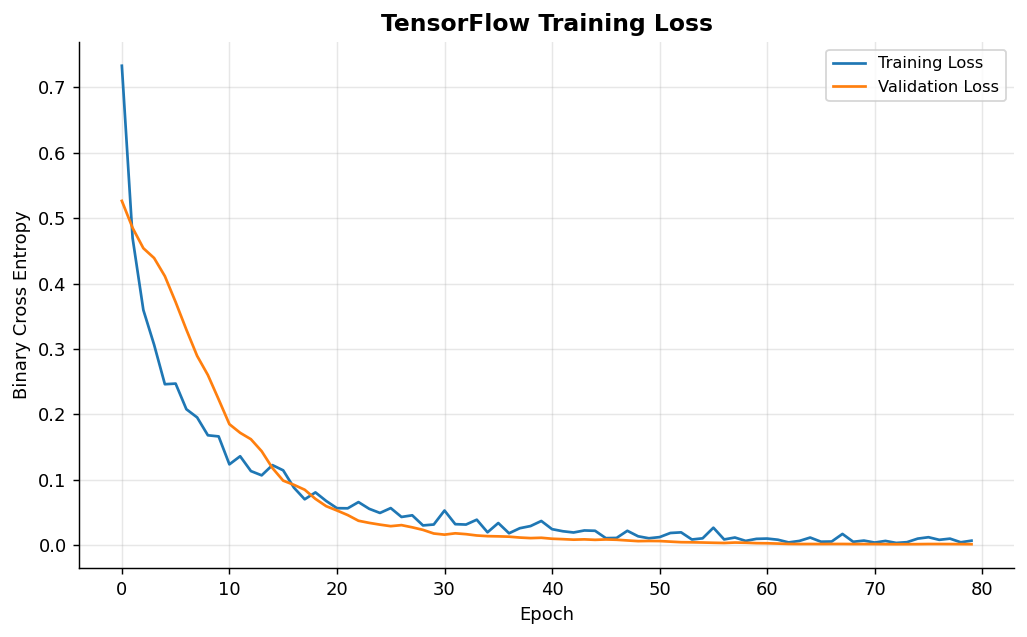

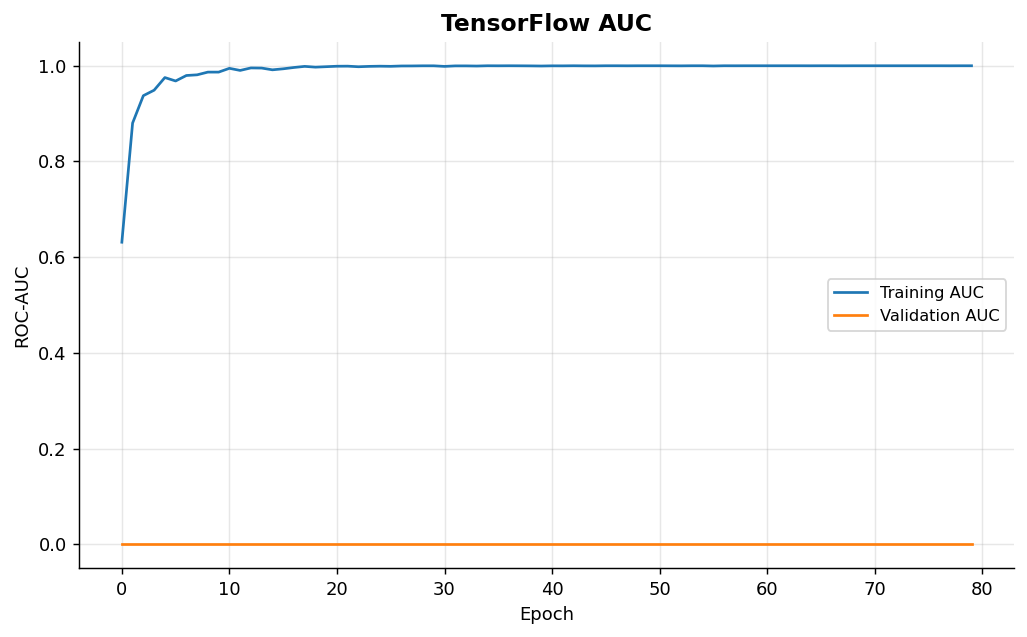


SAVED
/content/TENSORFLOW_FINAL_RESULTS.csv


In [ ]:
# ================================================================
# FAST TENSORFLOW DEEP LEARNING MODEL
# NO OOF
# NO NESTED CV
# NO COSINE
# NO LOGISTIC REGRESSION
# TRAIN ONCE
# ================================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE


# ================================================================
# 1. SEED
# ================================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


# ================================================================
# 2. LOAD DATA
# ================================================================

FILE = "/content/R1_R2_ALL_UNIQUE_ORDERED_v2.csv"

df = pd.read_csv(FILE).copy()

print("=" * 70)
print("DATA")
print("=" * 70)

print("Shape:", df.shape)


# ================================================================
# 3. TARGET
# ================================================================

if df["decision"].dtype == "object":

    df["decision"] = (
        df["decision"]
        .astype(str)
        .str.strip()
        .str.upper()
        .map({
            "APPROVE": 0,
            "DECLINE": 1
        })
    )

else:

    df["decision"] = pd.to_numeric(
        df["decision"],
        errors="coerce"
    )

if df["decision"].isna().any():
    raise ValueError("Target contains invalid / missing values.")

df["decision"] = df["decision"].astype(int)

y = df["decision"]


print("\nTarget distribution:")
print(y.value_counts())


# ================================================================
# 4. FEATURES
# ================================================================

X = df.drop(
    columns=[
        "id",
        "score",
        "decision"
    ],
    errors="ignore"
)


numeric_features = [
    "account_age_days",
    "account_balance",
    "amount",
    "beneficiaries",
    "linked_cards",
    "months_active",
    "recent_chargebacks",
    "trust_score",
    "utilisation"
]


categorical_features = [
    "channel"
]


print("\nML FEATURES:")
print(X.columns.tolist())


# ================================================================
# 5. TRAIN / TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=SEED
)


print("\nTrain:", len(X_train))
print("Test :", len(X_test))


# ================================================================
# 6. PREPROCESSING
# ================================================================

try:

    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:

    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )


numeric_pipe = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipe = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),

    (
        "onehot",
        ohe
    )
])


preprocessor = ColumnTransformer([

    (
        "numeric",
        numeric_pipe,
        numeric_features
    ),

    (
        "categorical",
        categorical_pipe,
        categorical_features
    )
])


# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


# ================================================================
# 7. SHOW PROCESSED COLUMNS
# ================================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


print("\n" + "=" * 70)
print("PROCESSED FEATURES")
print("=" * 70)

print(
    "TensorFlow input dimensions:",
    len(feature_names)
)

for i, feature in enumerate(feature_names):

    print(
        f"{i:2d} -> {feature}"
    )


# ================================================================
# 8. SMOTE
# ================================================================

smote = SMOTE(
    random_state=SEED
)


X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train_processed,
        y_train
    )
)


print("\n" + "=" * 70)
print("AFTER SMOTE")
print("=" * 70)

print(
    pd.Series(
        y_train_smote
    ).value_counts()
)


# ================================================================
# 9. TENSORFLOW MODEL
# ================================================================

tf.keras.backend.clear_session()


nn = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(
            X_train_smote.shape[1],
        )
    ),


    # First hidden layer
    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dropout(
        0.20
    ),


    # Second hidden layer
    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dropout(
        0.15
    ),


    # Third hidden layer
    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),


    # Binary output
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])


# ================================================================
# 10. COMPILE
# ================================================================

nn.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)


print("\n" + "=" * 70)
print("MODEL ARCHITECTURE")
print("=" * 70)

nn.summary()


# ================================================================
# 11. CALLBACKS
# ================================================================

early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True,

    verbose=1
)


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=4,

    min_lr=1e-5,

    verbose=1
)


# ================================================================
# 12. TRAIN
# ================================================================

print("\n" + "=" * 70)
print("TRAINING TENSORFLOW MODEL")
print("=" * 70)


history = nn.fit(

    X_train_smote,

    y_train_smote,

    validation_split=0.15,

    epochs=80,

    batch_size=16,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)


# ================================================================
# 13. TEST PREDICTIONS
# ================================================================

nn_probability = nn.predict(

    X_test_processed,

    verbose=0

).ravel()


# ================================================================
# 14. FINAL THRESHOLD
# ================================================================

THRESHOLD = 0.50


final_prediction = (

    nn_probability >= THRESHOLD

).astype(int)


# ================================================================
# 15. METRICS
# ================================================================

accuracy = accuracy_score(

    y_test,

    final_prediction
)


precision = precision_score(

    y_test,

    final_prediction,

    zero_division=0
)


recall = recall_score(

    y_test,

    final_prediction,

    zero_division=0
)


f1 = f1_score(

    y_test,

    final_prediction,

    zero_division=0
)


auc = roc_auc_score(

    y_test,

    nn_probability
)


ap = average_precision_score(

    y_test,

    nn_probability
)


# ================================================================
# 16. FINAL RESULTS
# ================================================================

print("\n" + "=" * 70)
print("FINAL TENSORFLOW RESULTS")
print("=" * 70)


print(
    f"\nROC-AUC:           {auc:.4f}"
)

print(
    f"Average Precision: {ap:.4f}"
)

print(
    f"Accuracy:          {accuracy:.4f}"
)

print(
    f"Precision DECLINE: {precision:.4f}"
)

print(
    f"Recall DECLINE:    {recall:.4f}"
)

print(
    f"F1 DECLINE:        {f1:.4f}"
)

print(
    f"Threshold:         {THRESHOLD:.2f}"
)


# ================================================================
# 17. CLASSIFICATION REPORT
# ================================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)


print(

    classification_report(

        y_test,

        final_prediction,

        target_names=[
            "APPROVE",
            "DECLINE"
        ],

        digits=4,

        zero_division=0
    )
)


# ================================================================
# 18. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(

    y_test,

    final_prediction
)


print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)


tn, fp, fn, tp = cm.ravel()


print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


# ================================================================
# 19. TRAINING CURVES
# ================================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    history.history["loss"],
    label="Training Loss"
)

ax.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

ax.set_title(
    "TensorFlow Training Loss"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Binary Cross Entropy"
)

ax.legend()

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ================================================================
# 20. AUC CURVE
# ================================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    history.history["auc"],
    label="Training AUC"
)

ax.plot(
    history.history["val_auc"],
    label="Validation AUC"
)

ax.set_title(
    "TensorFlow AUC"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.legend()

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ================================================================
# 21. SAVE TEST PREDICTIONS
# ================================================================

results = X_test.copy()


results["Actual"] = y_test.values


results["TF_Probability"] = (
    nn_probability
)


results["TF_Prediction"] = (
    final_prediction
)


OUTPUT = (
    "/content/"
    "TENSORFLOW_FINAL_RESULTS.csv"
)


results.to_csv(
    OUTPUT,
    index=False
)


print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(OUTPUT)

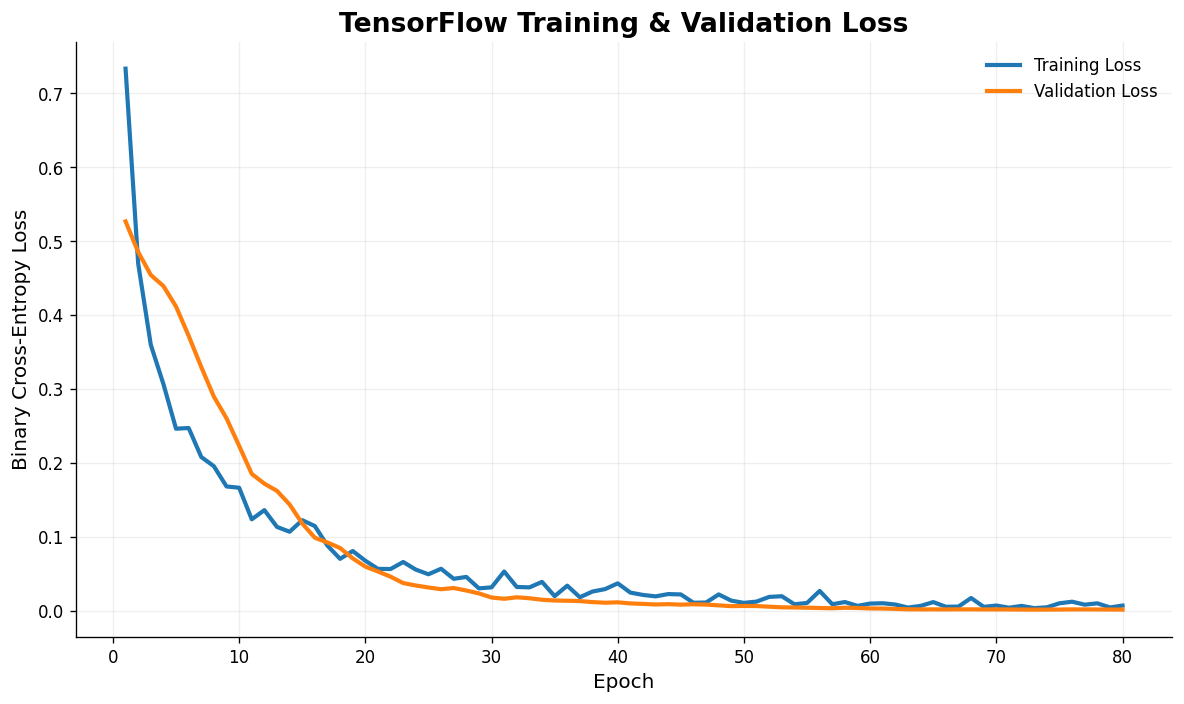

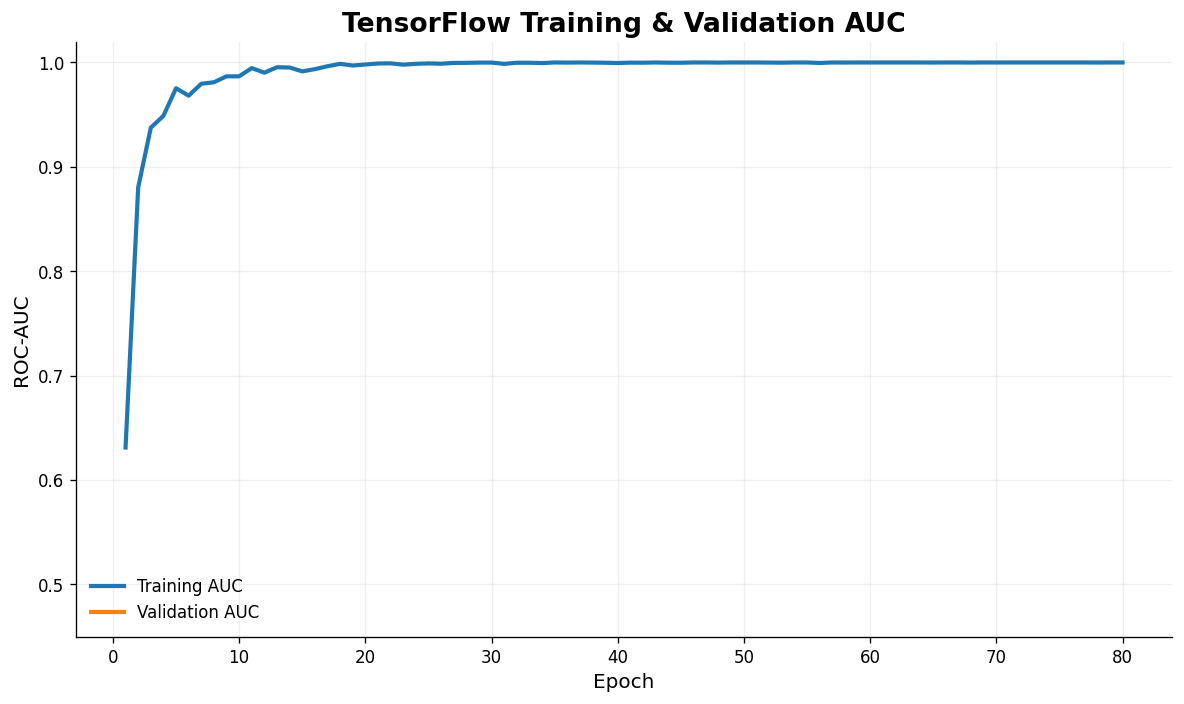

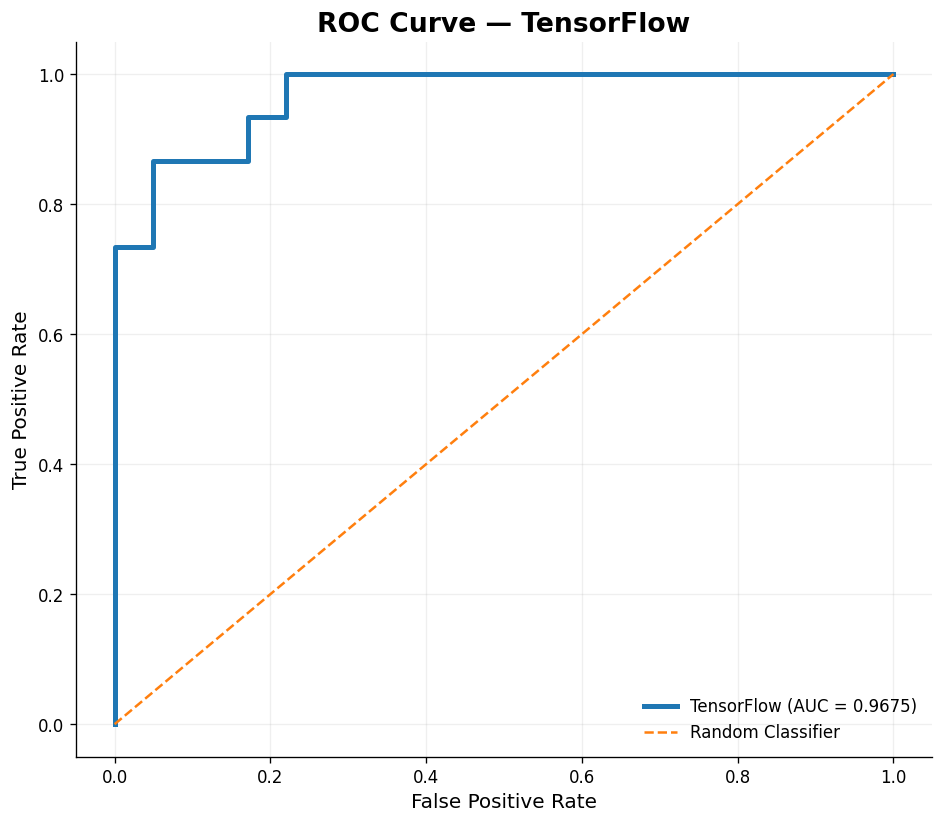

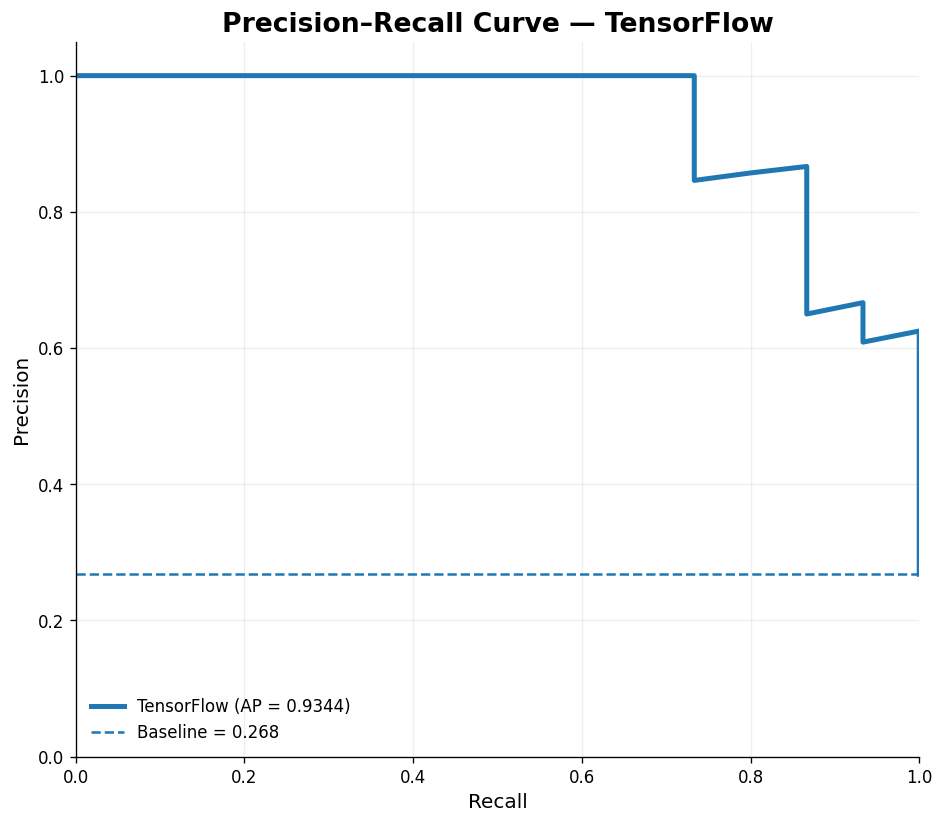

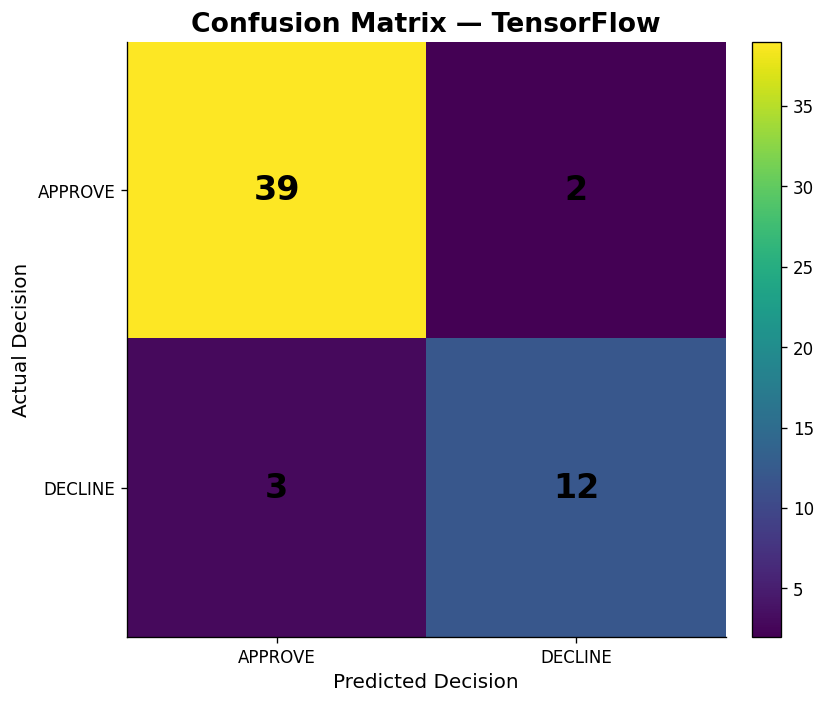

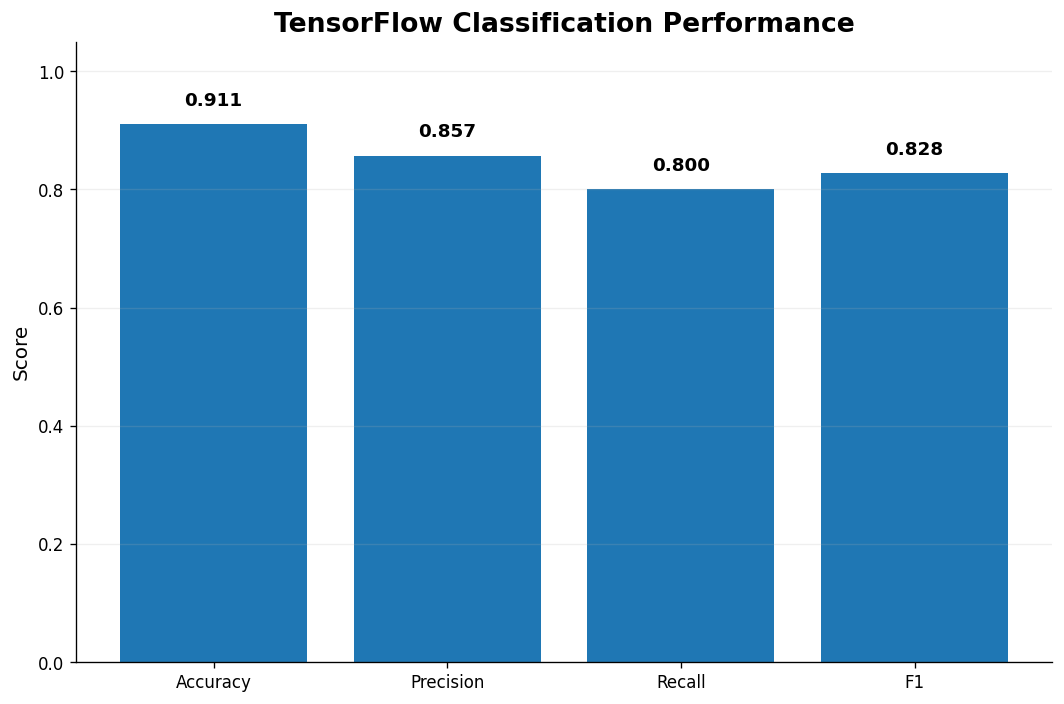

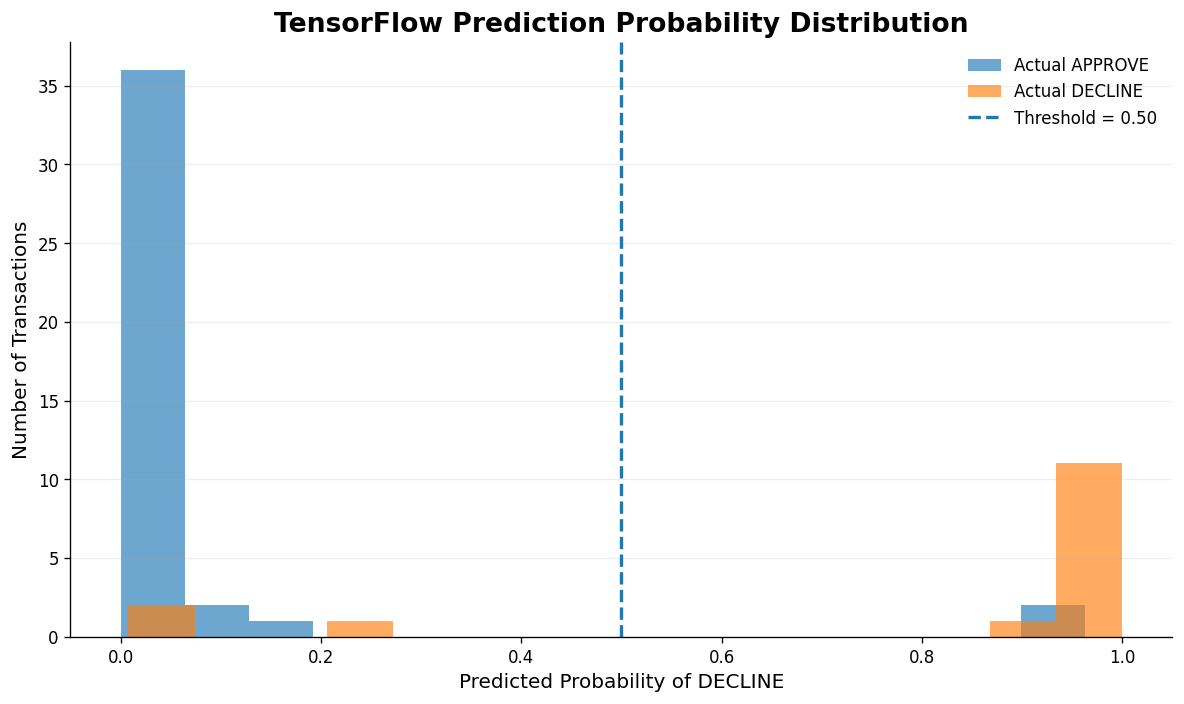

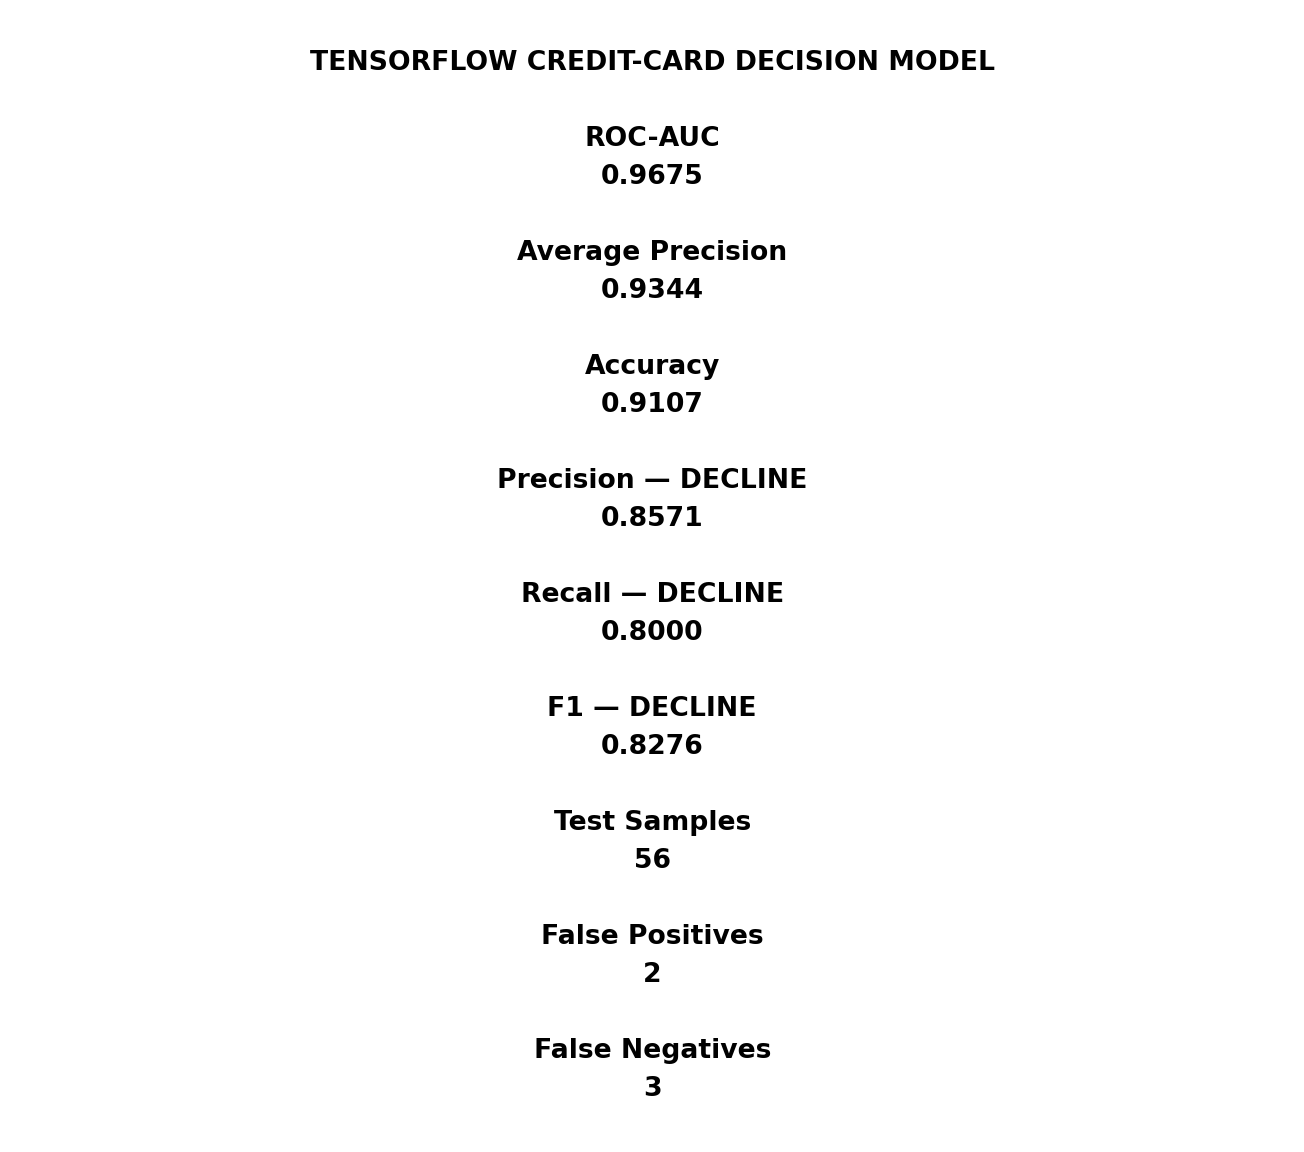

In [ ]:
# ================================================================
# BEAUTIFUL MODEL VISUALIZATIONS
# ================================================================

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)


# ================================================================
# 19. GLOBAL PLOT SETTINGS
# ================================================================

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})


# ================================================================
# 20. TRAINING LOSS
# ================================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

epochs = range(
    1,
    len(history.history["loss"]) + 1
)

ax.plot(
    epochs,
    history.history["loss"],
    linewidth=2.5,
    label="Training Loss"
)

ax.plot(
    epochs,
    history.history["val_loss"],
    linewidth=2.5,
    label="Validation Loss"
)

ax.set_title(
    "TensorFlow Training & Validation Loss"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Binary Cross-Entropy Loss"
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.20
)

plt.tight_layout()

plt.show()


# ================================================================
# 21. TRAINING AUC
# ================================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    epochs,
    history.history["auc"],
    linewidth=2.5,
    label="Training AUC"
)

ax.plot(
    epochs,
    history.history["val_auc"],
    linewidth=2.5,
    label="Validation AUC"
)

ax.set_title(
    "TensorFlow Training & Validation AUC"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.set_ylim(
    0.45,
    1.02
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.20
)

plt.tight_layout()

plt.show()


# ================================================================
# 22. ROC CURVE
# ================================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    nn_probability
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"TensorFlow (AUC = {auc:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

ax.set_title(
    "ROC Curve — TensorFlow"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.legend(
    frameon=False,
    loc="lower right"
)

ax.grid(
    alpha=0.20
)

plt.tight_layout()

plt.show()


# ================================================================
# 23. PRECISION-RECALL CURVE
# ================================================================

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_test,
        nn_probability
    )
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.plot(
    recall_curve,
    precision_curve,
    linewidth=3,
    label=f"TensorFlow (AP = {ap:.4f})"
)

ax.axhline(
    y=y_test.mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline = {y_test.mean():.3f}"
)

ax.set_title(
    "Precision–Recall Curve — TensorFlow"
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1.05
)

ax.legend(
    frameon=False,
    loc="lower left"
)

ax.grid(
    alpha=0.20
)

plt.tight_layout()

plt.show()


# ================================================================
# 24. CONFUSION MATRIX — BEAUTIFUL VERSION
# ================================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

im = ax.imshow(
    cm,
    interpolation="nearest",
    aspect="auto"
)

ax.set_title(
    "Confusion Matrix — TensorFlow"
)

ax.set_xlabel(
    "Predicted Decision"
)

ax.set_ylabel(
    "Actual Decision"
)

ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)

ax.set_xticklabels(
    ["APPROVE", "DECLINE"]
)

ax.set_yticklabels(
    ["APPROVE", "DECLINE"]
)


# Add values inside cells
for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            f"{cm[i, j]}",
            ha="center",
            va="center",
            fontsize=20,
            fontweight="bold"
        )


plt.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()

plt.show()


# ================================================================
# 25. CLASSIFICATION PERFORMANCE
# ================================================================

metrics_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

metrics_values = [
    accuracy,
    precision,
    recall,
    f1
]


fig, ax = plt.subplots(
    figsize=(9, 6)
)

bars = ax.bar(
    metrics_names,
    metrics_values
)

ax.set_title(
    "TensorFlow Classification Performance"
)

ax.set_ylabel(
    "Score"
)

ax.set_ylim(
    0,
    1.05
)

ax.grid(
    axis="y",
    alpha=0.20
)


# Add values above bars
for bar, value in zip(
    bars,
    metrics_values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )


plt.tight_layout()

plt.show()


# ================================================================
# 26. TEST PROBABILITY DISTRIBUTION
# ================================================================

approve_probs = nn_probability[
    y_test.values == 0
]

decline_probs = nn_probability[
    y_test.values == 1
]


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    approve_probs,
    bins=15,
    alpha=0.65,
    label="Actual APPROVE"
)

ax.hist(
    decline_probs,
    bins=15,
    alpha=0.65,
    label="Actual DECLINE"
)

ax.axvline(
    THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {THRESHOLD:.2f}"
)

ax.set_title(
    "TensorFlow Prediction Probability Distribution"
)

ax.set_xlabel(
    "Predicted Probability of DECLINE"
)

ax.set_ylabel(
    "Number of Transactions"
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.20
)

plt.tight_layout()

plt.show()


# ================================================================
# 27. SUMMARY DASHBOARD
# ================================================================

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.axis("off")


summary_text = f"""
TENSORFLOW CREDIT-CARD DECISION MODEL

ROC-AUC
{auc:.4f}

Average Precision
{ap:.4f}

Accuracy
{accuracy:.4f}

Precision — DECLINE
{precision:.4f}

Recall — DECLINE
{recall:.4f}

F1 — DECLINE
{f1:.4f}

Test Samples
{len(y_test)}

False Positives
{fp}

False Negatives
{fn}
"""


ax.text(
    0.50,
    0.50,
    summary_text,
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    linespacing=1.6
)

plt.tight_layout()

plt.show()

DATASET
Shape: (280, 13)

Target distribution:
decision
0    207
1     73
Name: count, dtype: int64

ML FEATURES:
['account_age_days', 'account_balance', 'amount', 'beneficiaries', 'channel', 'linked_cards', 'months_active', 'recent_chargebacks', 'trust_score', 'utilisation']

Train: 224
Test : 56

ADVANCED SCALING

Processing: Standard
Train: (224, 13)
Test : (56, 13)

Processing: Robust
Train: (224, 13)
Test : (56, 13)

Processing: Power
Train: (224, 13)
Test : (56, 13)

Processing: Quantile
Train: (224, 13)
Test : (56, 13)

SMOTE

Standard representation
decision
0    166
1    166
Name: count, dtype: int64

Robust representation
decision
0    166
1    166
Name: count, dtype: int64

Power representation
decision
0    166
1    166
Name: count, dtype: int64

Quantile representation
decision
0    166
1    166
Name: count, dtype: int64

Training: Logistic Regression — Standard

Training: Logistic Regression — Robust

Training: Logistic Regression — Power

Training: Logistic Regression — 

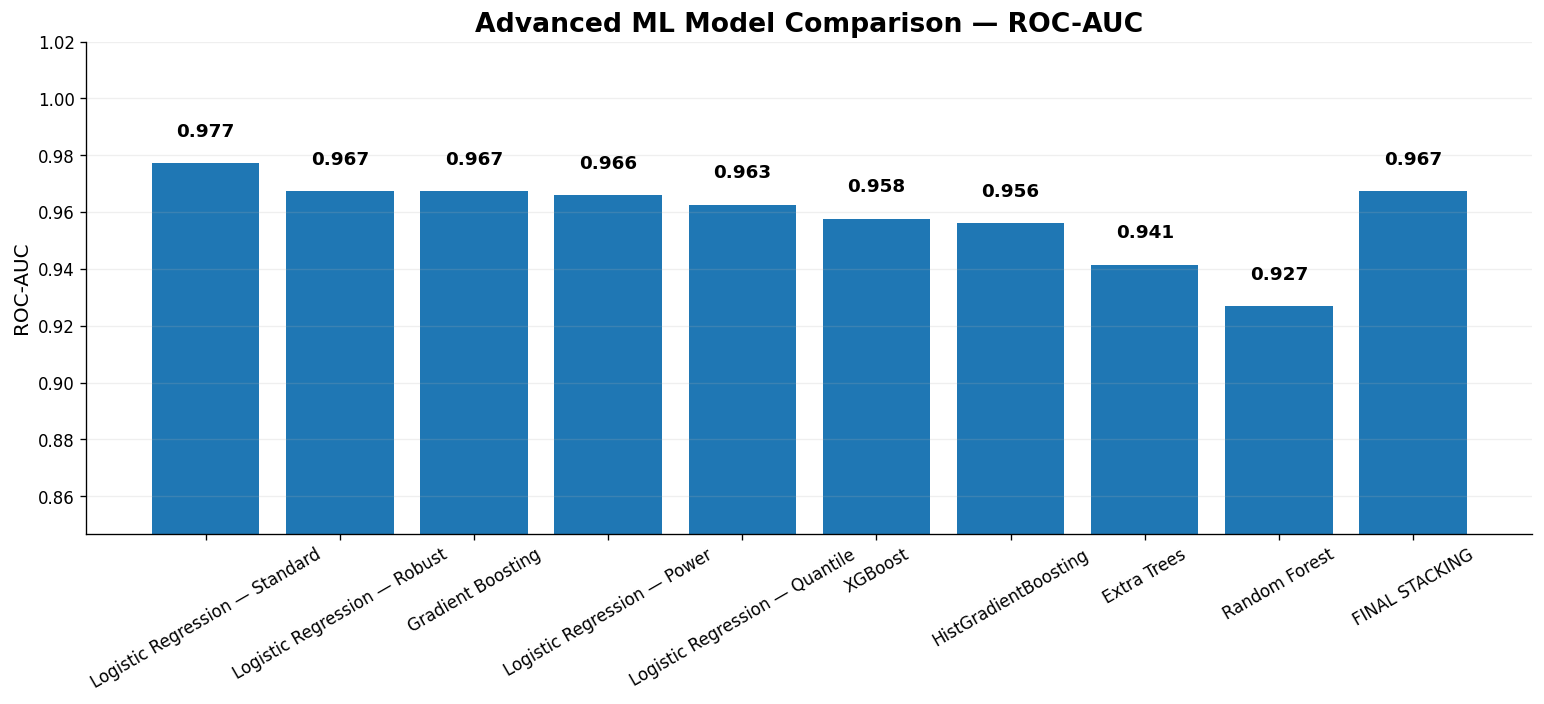

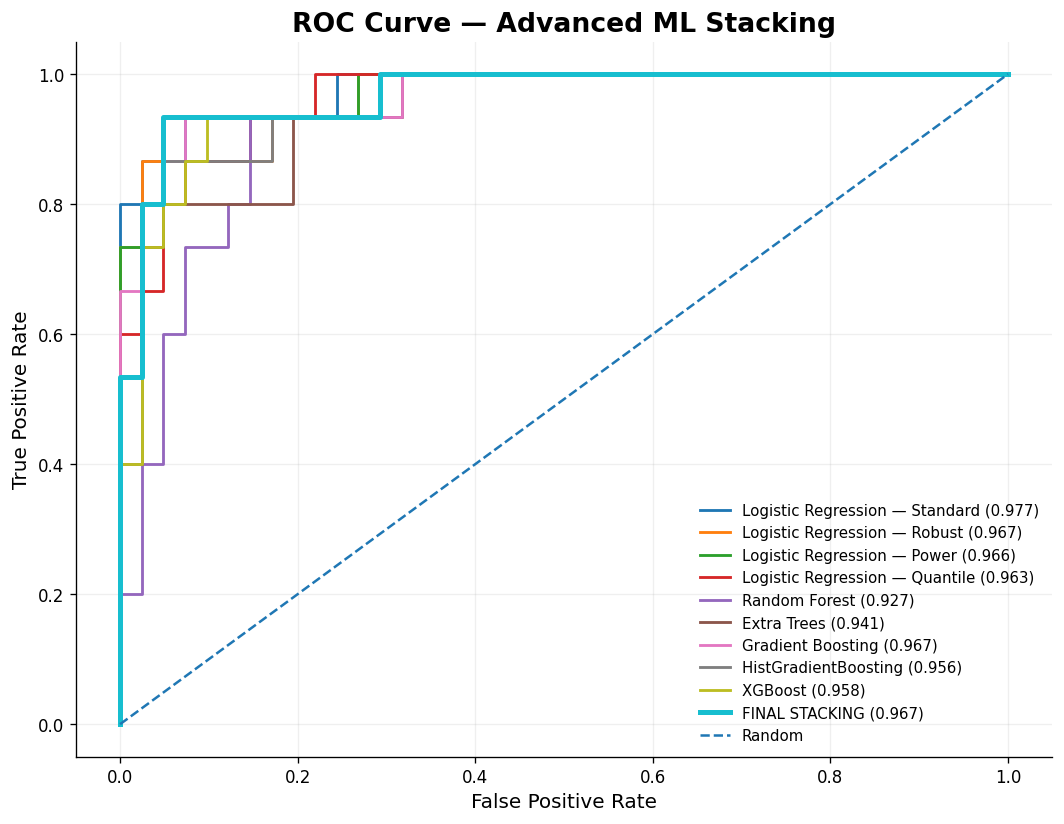

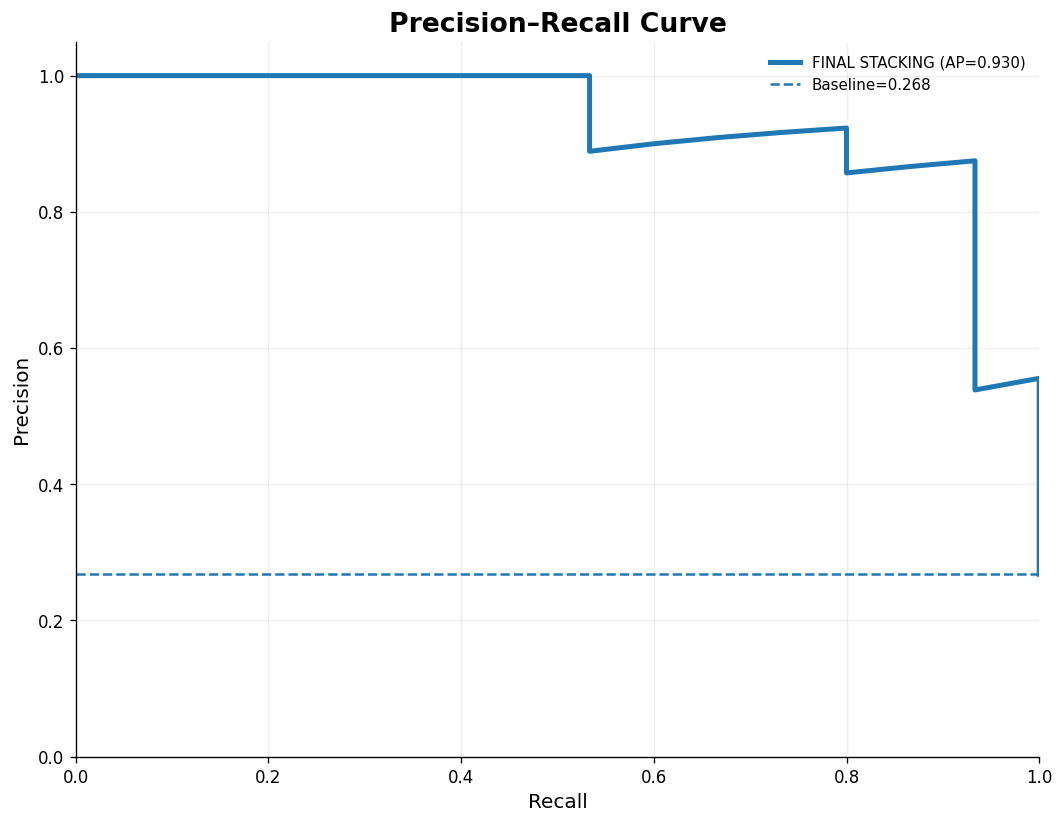

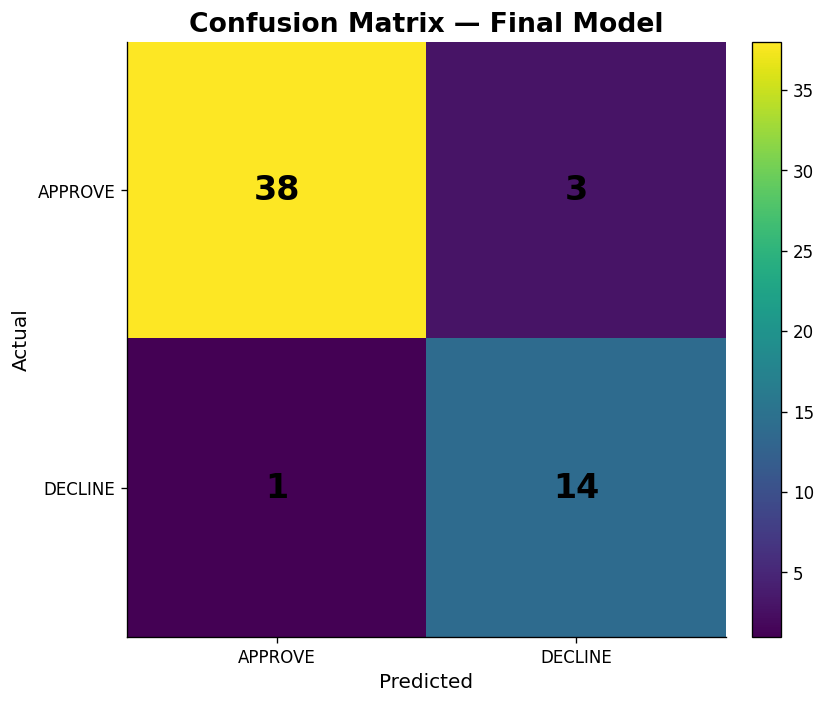

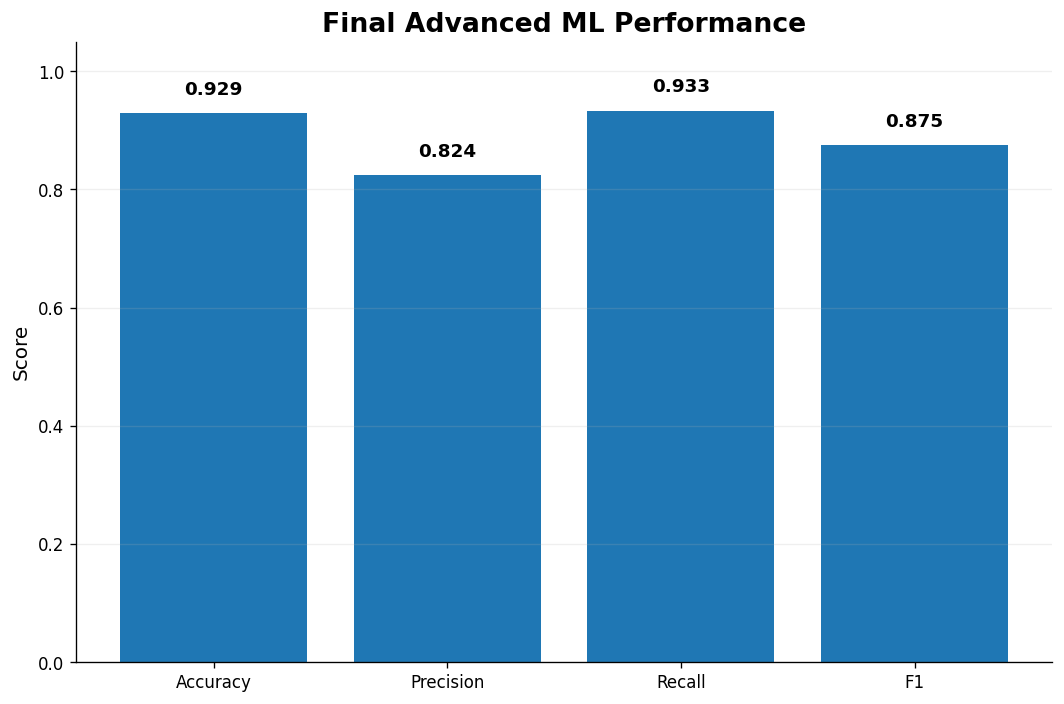

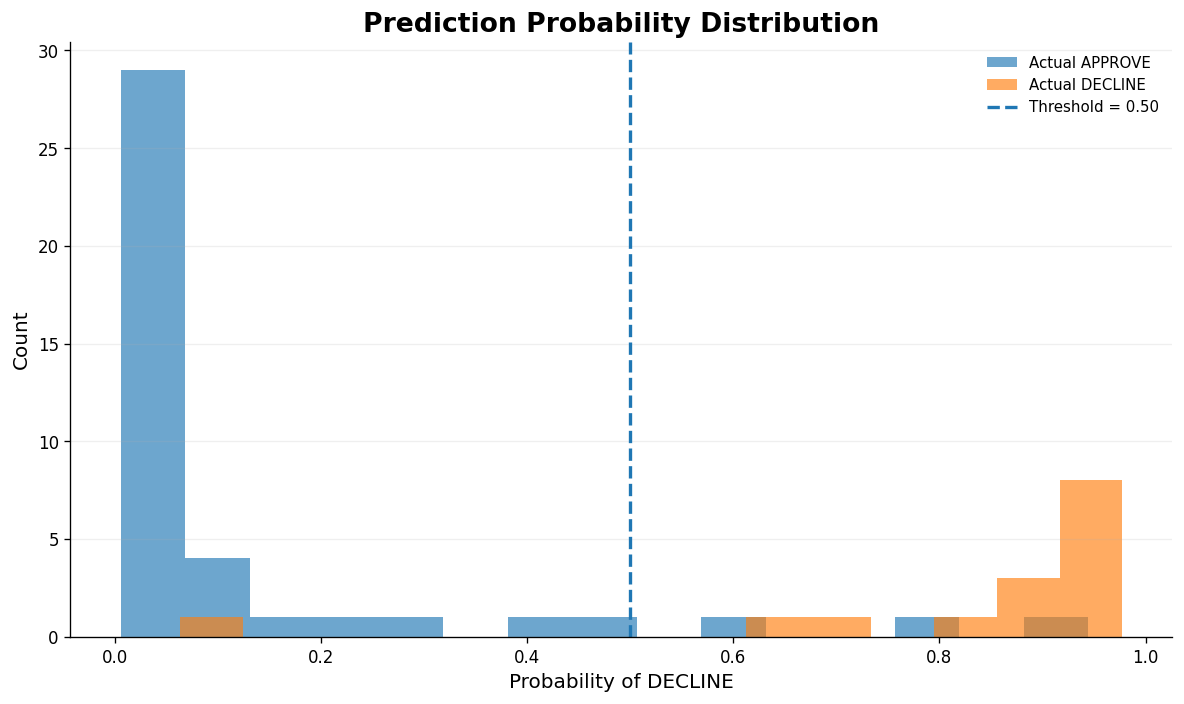

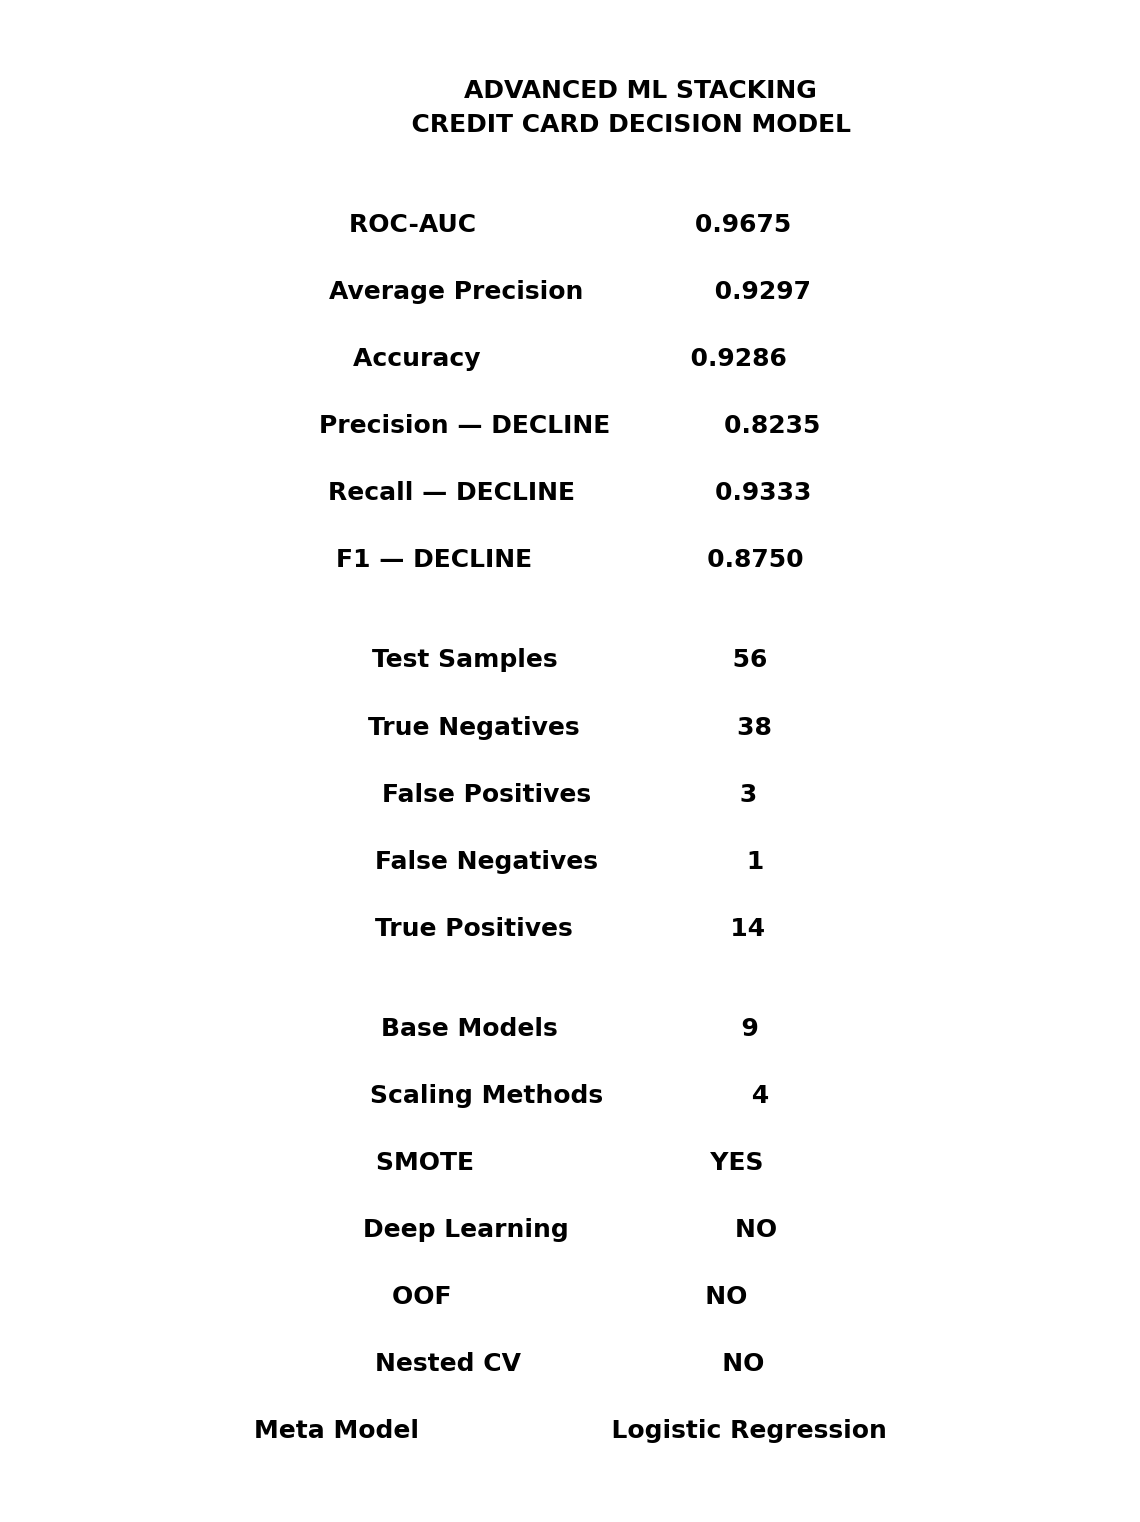


DONE

Predictions: /content/ADVANCED_ML_STACKING_RESULTS.csv
Model comparison: /content/ADVANCED_ML_MODEL_COMPARISON.csv
Summary: /content/ADVANCED_ML_SUMMARY.csv


In [ ]:
# ================================================================
# ADVANCED FAST ML STACKING
#
# NO DEEP LEARNING
# NO TENSORFLOW
# NO COSINE
# NO OOF
# NO NESTED CV
#
# TRAIN ONCE
# SMOTE
#
# ADVANCED SCALING:
#   1. StandardScaler
#   2. RobustScaler
#   3. PowerTransformer
#   4. QuantileTransformer
#
# MODELS:
#   Random Forest
#   Extra Trees
#   Gradient Boosting
#   HistGradientBoosting
#   Logistic Regression
#   XGBoost
#
# FINAL:
#   Logistic Regression Meta Model
# ================================================================


# ================================================================
# 1. IMPORTS
# ================================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    PowerTransformer,
    QuantileTransformer,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE


# ================================================================
# XGBOOST
# ================================================================

try:

    from xgboost import XGBClassifier

    XGBOOST_AVAILABLE = True

except ImportError:

    XGBOOST_AVAILABLE = False

    print("XGBoost not available.")


# ================================================================
# 2. SEED
# ================================================================

SEED = 42

np.random.seed(SEED)

random.seed(SEED)


# ================================================================
# 3. LOAD DATA
# ================================================================

FILE = "/content/R1_R2_ALL_UNIQUE_ORDERED_v2.csv"

df = pd.read_csv(FILE).copy()


print("=" * 75)
print("DATASET")
print("=" * 75)

print("Shape:", df.shape)


# ================================================================
# 4. TARGET
# ================================================================

if df["decision"].dtype == "object":

    df["decision"] = (

        df["decision"]

        .astype(str)

        .str.strip()

        .str.upper()

        .map({
            "APPROVE": 0,
            "DECLINE": 1
        })

    )

else:

    df["decision"] = pd.to_numeric(
        df["decision"],
        errors="coerce"
    )


if df["decision"].isna().any():

    raise ValueError(
        "Invalid values found in decision column."
    )


df["decision"] = df["decision"].astype(int)

y = df["decision"]


print("\nTarget distribution:")

print(y.value_counts())


# ================================================================
# 5. FEATURES
# ================================================================

X = df.drop(

    columns=[
        "id",
        "score",
        "decision"
    ],

    errors="ignore"

)


numeric_features = [

    "account_age_days",

    "account_balance",

    "amount",

    "beneficiaries",

    "linked_cards",

    "months_active",

    "recent_chargebacks",

    "trust_score",

    "utilisation"

]


categorical_features = [

    "channel"

]


print("\nML FEATURES:")

print(X.columns.tolist())


# ================================================================
# 6. TRAIN TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=SEED

)


print("\nTrain:", len(X_train))

print("Test :", len(X_test))


# ================================================================
# 7. ONE-HOT ENCODER
# ================================================================

try:

    ohe_template = OneHotEncoder(

        handle_unknown="ignore",

        sparse_output=False

    )

except TypeError:

    ohe_template = OneHotEncoder(

        handle_unknown="ignore",

        sparse=False

    )


# ================================================================
# 8. PREPROCESSOR FUNCTION
# ================================================================

def create_preprocessor(scaler):

    numeric_pipeline = Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",

            scaler
        )

    ])


    categorical_pipeline = Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",

            ohe_template
        )

    ])


    return ColumnTransformer([

        (
            "numeric",

            numeric_pipeline,

            numeric_features
        ),

        (
            "categorical",

            categorical_pipeline,

            categorical_features
        )

    ])


# ================================================================
# 9. CREATE MULTIPLE FEATURE REPRESENTATIONS
# ================================================================

preprocessors = {

    "Standard": create_preprocessor(

        StandardScaler()

    ),

    "Robust": create_preprocessor(

        RobustScaler(
            quantile_range=(10, 90)
        )

    ),

    "Power": create_preprocessor(

        PowerTransformer(
            method="yeo-johnson",
            standardize=True
        )

    ),

    "Quantile": create_preprocessor(

        QuantileTransformer(
            n_quantiles=50,
            output_distribution="normal",
            random_state=SEED
        )

    )

}


# ================================================================
# 10. PROCESS ALL REPRESENTATIONS
# ================================================================

processed_train = {}

processed_test = {}


print("\n" + "=" * 75)

print("ADVANCED SCALING")

print("=" * 75)


for name, processor in preprocessors.items():

    print(

        "\nProcessing:",

        name

    )


    train_matrix = (

        processor.fit_transform(

            X_train

        )

    )


    test_matrix = (

        processor.transform(

            X_test

        )

    )


    processed_train[name] = train_matrix

    processed_test[name] = test_matrix


    print(

        "Train:",

        train_matrix.shape

    )


    print(

        "Test :",

        test_matrix.shape

    )


# ================================================================
# 11. SMOTE FOR EACH REPRESENTATION
# ================================================================

smote_train = {}


print("\n" + "=" * 75)

print("SMOTE")

print("=" * 75)


for name in processed_train:

    smote = SMOTE(

        random_state=SEED,

        k_neighbors=5

    )


    X_smote, y_smote = (

        smote.fit_resample(

            processed_train[name],

            y_train

        )

    )


    smote_train[name] = (

        X_smote,

        y_smote

    )


    print(

        f"\n{name} representation"

    )


    print(

        pd.Series(

            y_smote

        ).value_counts()

    )


# ================================================================
# 12. BASE MODEL STORAGE
# ================================================================

trained_models = {}

train_predictions = {}

test_predictions = {}

model_results = []


# ================================================================
# 13. LOGISTIC REGRESSION
# ================================================================
#
# Logistic Regression benefits strongly from scaling.
#
# We therefore train FOUR versions:
#
# Standard
# Robust
# Power
# Quantile
# ================================================================


for scaler_name in [

    "Standard",

    "Robust",

    "Power",

    "Quantile"

]:

    model_name = (

        f"Logistic Regression — {scaler_name}"

    )


    model = LogisticRegression(

        C=0.7,

        max_iter=3000,

        solver="lbfgs",

        random_state=SEED

    )


    X_smote, y_smote = smote_train[

        scaler_name

    ]


    print(

        "\nTraining:",

        model_name

    )


    model.fit(

        X_smote,

        y_smote

    )


    train_probability = (

        model.predict_proba(

            X_smote

        )[:, 1]

    )


    test_probability = (

        model.predict_proba(

            processed_test[scaler_name]

        )[:, 1]

    )


    trained_models[model_name] = model

    train_predictions[model_name] = train_probability

    test_predictions[model_name] = test_probability


    prediction = (

        test_probability >= 0.50

    ).astype(int)


    model_results.append({

        "Model": model_name,

        "ROC-AUC": roc_auc_score(

            y_test,

            test_probability

        ),

        "Average Precision":

            average_precision_score(

                y_test,

                test_probability

            ),

        "Accuracy":

            accuracy_score(

                y_test,

                prediction

            ),

        "F1":

            f1_score(

                y_test,

                prediction,

                zero_division=0

            )

    })


# ================================================================
# 14. TREE MODELS
# ================================================================
#
# Trees don't require scaling.
#
# We use the Robust representation simply to keep the data
# representation consistent and SMOTE-compatible.
# ================================================================

TREE_REPRESENTATION = "Robust"


tree_models = {}


# ------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------

tree_models["Random Forest"] = (

    RandomForestClassifier(

        n_estimators=350,

        max_depth=10,

        min_samples_leaf=2,

        max_features="sqrt",

        random_state=SEED,

        n_jobs=-1

    )

)


# ------------------------------------------------
# EXTRA TREES
# ------------------------------------------------

tree_models["Extra Trees"] = (

    ExtraTreesClassifier(

        n_estimators=350,

        max_depth=None,

        min_samples_leaf=1,

        max_features="sqrt",

        random_state=SEED,

        n_jobs=-1

    )

)


# ------------------------------------------------
# GRADIENT BOOSTING
# ------------------------------------------------

tree_models["Gradient Boosting"] = (

    GradientBoostingClassifier(

        n_estimators=250,

        learning_rate=0.035,

        max_depth=2,

        min_samples_leaf=3,

        subsample=0.9,

        random_state=SEED

    )

)


# ------------------------------------------------
# HISTOGRAM GRADIENT BOOSTING
# ------------------------------------------------

tree_models["HistGradientBoosting"] = (

    HistGradientBoostingClassifier(

        max_iter=250,

        learning_rate=0.04,

        max_leaf_nodes=15,

        min_samples_leaf=5,

        l2_regularization=1.0,

        random_state=SEED

    )

)


# ------------------------------------------------
# XGBOOST
# ------------------------------------------------

if XGBOOST_AVAILABLE:

    tree_models["XGBoost"] = (

        XGBClassifier(

            n_estimators=250,

            max_depth=3,

            learning_rate=0.035,

            subsample=0.90,

            colsample_bytree=0.90,

            min_child_weight=2,

            reg_alpha=0.05,

            reg_lambda=2.0,

            objective="binary:logistic",

            eval_metric="logloss",

            tree_method="hist",

            random_state=SEED,

            n_jobs=-1

        )

    )


# ================================================================
# 15. TRAIN TREE MODELS
# ================================================================

X_tree_train, y_tree_train = smote_train[

    TREE_REPRESENTATION

]


X_tree_test = processed_test[

    TREE_REPRESENTATION

]


for name, model in tree_models.items():

    print(

        "\nTraining:",

        name

    )


    model.fit(

        X_tree_train,

        y_tree_train

    )


    train_probability = (

        model.predict_proba(

            X_tree_train

        )[:, 1]

    )


    test_probability = (

        model.predict_proba(

            X_tree_test

        )[:, 1]

    )


    trained_models[name] = model

    train_predictions[name] = train_probability

    test_predictions[name] = test_probability


    prediction = (

        test_probability >= 0.50

    ).astype(int)


    model_results.append({

        "Model": name,

        "ROC-AUC": roc_auc_score(

            y_test,

            test_probability

        ),

        "Average Precision":

            average_precision_score(

                y_test,

                test_probability

            ),

        "Accuracy":

            accuracy_score(

                y_test,

                prediction

            ),

        "F1":

            f1_score(

                y_test,

                prediction,

                zero_division=0

            )

    })


# ================================================================
# 16. CREATE STACKING MATRICES
# ================================================================

model_names = list(

    test_predictions.keys()

)


X_stack_train = np.column_stack([

    train_predictions[name]

    for name in model_names

])


X_stack_test = np.column_stack([

    test_predictions[name]

    for name in model_names

])


print("\n" + "=" * 75)

print("STACKING")

print("=" * 75)


print(

    "Number of base models:",

    len(model_names)

)


print(

    "Stack train shape:",

    X_stack_train.shape

)


print(

    "Stack test shape:",

    X_stack_test.shape

)


# ================================================================
# 17. META MODEL
# ================================================================

meta_model = LogisticRegression(

    C=0.5,

    max_iter=3000,

    solver="lbfgs",

    random_state=SEED

)


print("\nTraining META MODEL...")


meta_model.fit(

    X_stack_train,

    y_tree_train

)


stack_probability = (

    meta_model

    .predict_proba(

        X_stack_test

    )[:, 1]

)


# ================================================================
# 18. WEIGHTED PROBABILITY BLENDING
# ================================================================

#
# The scaling-specific Logistic Regression models receive
# slightly lower individual weights because they are correlated.
#
# Tree models receive slightly higher weights.
#

weights = []


for name in model_names:

    if name in [

        "Gradient Boosting",

        "XGBoost",

        "Extra Trees"

    ]:

        weights.append(1.15)

    elif name == "HistGradientBoosting":

        weights.append(1.10)

    else:

        weights.append(1.00)


weights = np.array(weights)


weights = (

    weights /

    weights.sum()

)


blend_probability = np.average(

    X_stack_test,

    axis=1,

    weights=weights

)


# ================================================================
# 19. FINAL PROBABILITY
# ================================================================

FINAL_STACK_WEIGHT = 0.75

FINAL_BLEND_WEIGHT = 0.25


final_probability = (

    FINAL_STACK_WEIGHT *

    stack_probability

    +

    FINAL_BLEND_WEIGHT *

    blend_probability

)


# ================================================================
# 20. FINAL THRESHOLD
# ================================================================

THRESHOLD = 0.50


final_prediction = (

    final_probability >= THRESHOLD

).astype(int)


# ================================================================
# 21. FINAL METRICS
# ================================================================

accuracy = accuracy_score(

    y_test,

    final_prediction

)


precision = precision_score(

    y_test,

    final_prediction,

    zero_division=0

)


recall = recall_score(

    y_test,

    final_prediction,

    zero_division=0

)


f1 = f1_score(

    y_test,

    final_prediction,

    zero_division=0

)


auc = roc_auc_score(

    y_test,

    final_probability

)


ap = average_precision_score(

    y_test,

    final_probability

)


# ================================================================
# 22. MODEL RESULTS
# ================================================================

model_results_df = pd.DataFrame(

    model_results

)


model_results_df = (

    model_results_df

    .sort_values(

        "ROC-AUC",

        ascending=False

    )

    .reset_index(drop=True)

)


print("\n" + "=" * 75)

print("MODEL COMPARISON")

print("=" * 75)


print(

    model_results_df.to_string(

        index=False,

        float_format=lambda x: f"{x:.4f}"

    )

)


# ================================================================
# 23. FINAL RESULTS
# ================================================================

print("\n" + "=" * 75)

print("FINAL ADVANCED ML STACKING")

print("=" * 75)


print(

    f"\nROC-AUC:           {auc:.4f}"

)


print(

    f"Average Precision: {ap:.4f}"

)


print(

    f"Accuracy:          {accuracy:.4f}"

)


print(

    f"Precision DECLINE: {precision:.4f}"

)


print(

    f"Recall DECLINE:    {recall:.4f}"

)


print(

    f"F1 DECLINE:        {f1:.4f}"

)


# ================================================================
# 24. CLASSIFICATION REPORT
# ================================================================

print("\n" + "=" * 75)

print("CLASSIFICATION REPORT")

print("=" * 75)


print(

    classification_report(

        y_test,

        final_prediction,

        target_names=[

            "APPROVE",

            "DECLINE"

        ],

        digits=4,

        zero_division=0

    )

)


# ================================================================
# 25. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(

    y_test,

    final_prediction

)


tn, fp, fn, tp = cm.ravel()


print("\n" + "=" * 75)

print("CONFUSION MATRIX")

print("=" * 75)


print(cm)


print("\nTN:", tn)

print("FP:", fp)

print("FN:", fn)

print("TP:", tp)


# ================================================================
# 26. VISUAL STYLE
# ================================================================

plt.rcParams.update({

    "figure.dpi": 120,

    "savefig.dpi": 180,

    "font.size": 11,

    "axes.titlesize": 16,

    "axes.labelsize": 12,

    "axes.titleweight": "bold",

    "axes.spines.top": False,

    "axes.spines.right": False,

    "legend.fontsize": 9

})


# ================================================================
# 27. MODEL COMPARISON GRAPH
# ================================================================

plot_df = model_results_df.copy()


plot_df.loc[len(plot_df)] = {

    "Model": "FINAL STACKING",

    "ROC-AUC": auc,

    "Average Precision": ap,

    "Accuracy": accuracy,

    "F1": f1

}


fig, ax = plt.subplots(

    figsize=(13, 6)

)


bars = ax.bar(

    plot_df["Model"],

    plot_df["ROC-AUC"]

)


ax.set_title(

    "Advanced ML Model Comparison — ROC-AUC"

)


ax.set_ylabel(

    "ROC-AUC"

)


ax.set_ylim(

    max(

        0,

        plot_df["ROC-AUC"].min() - 0.08

    ),

    1.02

)


ax.tick_params(

    axis="x",

    rotation=30

)


ax.grid(

    axis="y",

    alpha=0.20

)


for bar, value in zip(

    bars,

    plot_df["ROC-AUC"]

):

    ax.text(

        bar.get_x() +

        bar.get_width() / 2,

        value + 0.008,

        f"{value:.3f}",

        ha="center",

        va="bottom",

        fontweight="bold"

    )


plt.tight_layout()

plt.show()


# ================================================================
# 28. ROC CURVE
# ================================================================

fig, ax = plt.subplots(

    figsize=(9, 7)

)


for name in model_names:

    probability = test_predictions[name]


    fpr, tpr, _ = roc_curve(

        y_test,

        probability

    )


    model_auc = roc_auc_score(

        y_test,

        probability

    )


    ax.plot(

        fpr,

        tpr,

        linewidth=1.7,

        label=f"{name} ({model_auc:.3f})"

    )


fpr_final, tpr_final, _ = roc_curve(

    y_test,

    final_probability

)


ax.plot(

    fpr_final,

    tpr_final,

    linewidth=3,

    label=f"FINAL STACKING ({auc:.3f})"

)


ax.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    linewidth=1.5,

    label="Random"

)


ax.set_title(

    "ROC Curve — Advanced ML Stacking"

)


ax.set_xlabel(

    "False Positive Rate"

)


ax.set_ylabel(

    "True Positive Rate"

)


ax.legend(

    frameon=False,

    loc="lower right"

)


ax.grid(

    alpha=0.20

)


plt.tight_layout()

plt.show()


# ================================================================
# 29. PRECISION RECALL
# ================================================================

precision_curve, recall_curve, _ = (

    precision_recall_curve(

        y_test,

        final_probability

    )

)


fig, ax = plt.subplots(

    figsize=(9, 7)

)


ax.plot(

    recall_curve,

    precision_curve,

    linewidth=3,

    label=f"FINAL STACKING (AP={ap:.3f})"

)


ax.axhline(

    y=y_test.mean(),

    linestyle="--",

    linewidth=1.5,

    label=f"Baseline={y_test.mean():.3f}"

)


ax.set_title(

    "Precision–Recall Curve"

)


ax.set_xlabel(

    "Recall"

)


ax.set_ylabel(

    "Precision"

)


ax.set_xlim(

    0,

    1

)


ax.set_ylim(

    0,

    1.05

)


ax.legend(

    frameon=False

)


ax.grid(

    alpha=0.20

)


plt.tight_layout()

plt.show()


# ================================================================
# 30. CONFUSION MATRIX GRAPH
# ================================================================

fig, ax = plt.subplots(

    figsize=(7, 6)

)


im = ax.imshow(

    cm,

    interpolation="nearest",

    aspect="auto"

)


ax.set_title(

    "Confusion Matrix — Final Model"

)


ax.set_xlabel(

    "Predicted"

)


ax.set_ylabel(

    "Actual"

)


ax.set_xticks([0, 1])

ax.set_yticks([0, 1])


ax.set_xticklabels([

    "APPROVE",

    "DECLINE"

])


ax.set_yticklabels([

    "APPROVE",

    "DECLINE"

])


for i in range(2):

    for j in range(2):

        ax.text(

            j,

            i,

            str(cm[i, j]),

            ha="center",

            va="center",

            fontsize=20,

            fontweight="bold"

        )


plt.colorbar(

    im,

    ax=ax,

    fraction=0.046,

    pad=0.04

)


plt.tight_layout()

plt.show()


# ================================================================
# 31. PERFORMANCE GRAPH
# ================================================================

metric_names = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1"

]


metric_values = [

    accuracy,

    precision,

    recall,

    f1

]


fig, ax = plt.subplots(

    figsize=(9, 6)

)


bars = ax.bar(

    metric_names,

    metric_values

)


ax.set_title(

    "Final Advanced ML Performance"

)


ax.set_ylabel(

    "Score"

)


ax.set_ylim(

    0,

    1.05

)


ax.grid(

    axis="y",

    alpha=0.20

)


for bar, value in zip(

    bars,

    metric_values

):

    ax.text(

        bar.get_x() +

        bar.get_width() / 2,

        value + 0.025,

        f"{value:.3f}",

        ha="center",

        va="bottom",

        fontweight="bold"

    )


plt.tight_layout()

plt.show()


# ================================================================
# 32. PROBABILITY DISTRIBUTION
# ================================================================

approve_probs = final_probability[

    y_test.values == 0

]


decline_probs = final_probability[

    y_test.values == 1

]


fig, ax = plt.subplots(

    figsize=(10, 6)

)


ax.hist(

    approve_probs,

    bins=15,

    alpha=0.65,

    label="Actual APPROVE"

)


ax.hist(

    decline_probs,

    bins=15,

    alpha=0.65,

    label="Actual DECLINE"

)


ax.axvline(

    THRESHOLD,

    linestyle="--",

    linewidth=2,

    label=f"Threshold = {THRESHOLD:.2f}"

)


ax.set_title(

    "Prediction Probability Distribution"

)


ax.set_xlabel(

    "Probability of DECLINE"

)


ax.set_ylabel(

    "Count"

)


ax.legend(

    frameon=False

)


ax.grid(

    axis="y",

    alpha=0.20

)


plt.tight_layout()

plt.show()


# ================================================================
# 33. FINAL DASHBOARD
# ================================================================

fig, ax = plt.subplots(

    figsize=(12, 7)

)


ax.axis("off")


dashboard = f"""

                ADVANCED ML STACKING
              CREDIT CARD DECISION MODEL


ROC-AUC                         {auc:.4f}

Average Precision               {ap:.4f}

Accuracy                        {accuracy:.4f}

Precision — DECLINE             {precision:.4f}

Recall — DECLINE                {recall:.4f}

F1 — DECLINE                    {f1:.4f}


Test Samples                    {len(y_test)}

True Negatives                  {tn}

False Positives                 {fp}

False Negatives                 {fn}

True Positives                  {tp}


Base Models                     {len(model_names)}

Scaling Methods                 4

SMOTE                           YES

Deep Learning                   NO

OOF                             NO

Nested CV                       NO

Meta Model                      Logistic Regression

"""


ax.text(

    0.50,

    0.50,

    dashboard,

    ha="center",

    va="center",

    fontsize=15,

    fontweight="bold",

    linespacing=1.5

)


plt.tight_layout()

plt.show()


# ================================================================
# 34. SAVE TEST PREDICTIONS
# ================================================================

results = X_test.copy()


results["Actual"] = y_test.values


results["Final_Probability"] = final_probability


results["Final_Prediction"] = final_prediction


results["Stack_Probability"] = stack_probability


results["Blend_Probability"] = blend_probability


for name in model_names:

    safe_name = (

        name

        .replace(" ", "_")

        .replace("—", "")

        .replace("-", "_")

    )


    results[

        f"{safe_name}_Probability"

    ] = test_predictions[name]


OUTPUT = (

    "/content/"

    "ADVANCED_ML_STACKING_RESULTS.csv"

)


results.to_csv(

    OUTPUT,

    index=False

)


# ================================================================
# 35. SAVE MODEL COMPARISON
# ================================================================

MODEL_OUTPUT = (

    "/content/"

    "ADVANCED_ML_MODEL_COMPARISON.csv"

)


plot_df.to_csv(

    MODEL_OUTPUT,

    index=False

)


# ================================================================
# 36. SAVE SUMMARY
# ================================================================

summary_df = pd.DataFrame({

    "Metric": [

        "ROC-AUC",

        "Average Precision",

        "Accuracy",

        "Precision DECLINE",

        "Recall DECLINE",

        "F1 DECLINE",

        "Threshold",

        "Test Samples",

        "TN",

        "FP",

        "FN",

        "TP"

    ],

    "Value": [

        auc,

        ap,

        accuracy,

        precision,

        recall,

        f1,

        THRESHOLD,

        len(y_test),

        tn,

        fp,

        fn,

        tp

    ]

})


SUMMARY_OUTPUT = (

    "/content/"

    "ADVANCED_ML_SUMMARY.csv"

)


summary_df.to_csv(

    SUMMARY_OUTPUT,

    index=False

)


# ================================================================
# 37. DONE
# ================================================================

print("\n" + "=" * 75)

print("DONE")

print("=" * 75)


print(

    "\nPredictions:",

    OUTPUT

)


print(

    "Model comparison:",

    MODEL_OUTPUT

)


print(

    "Summary:",

    SUMMARY_OUTPUT

)

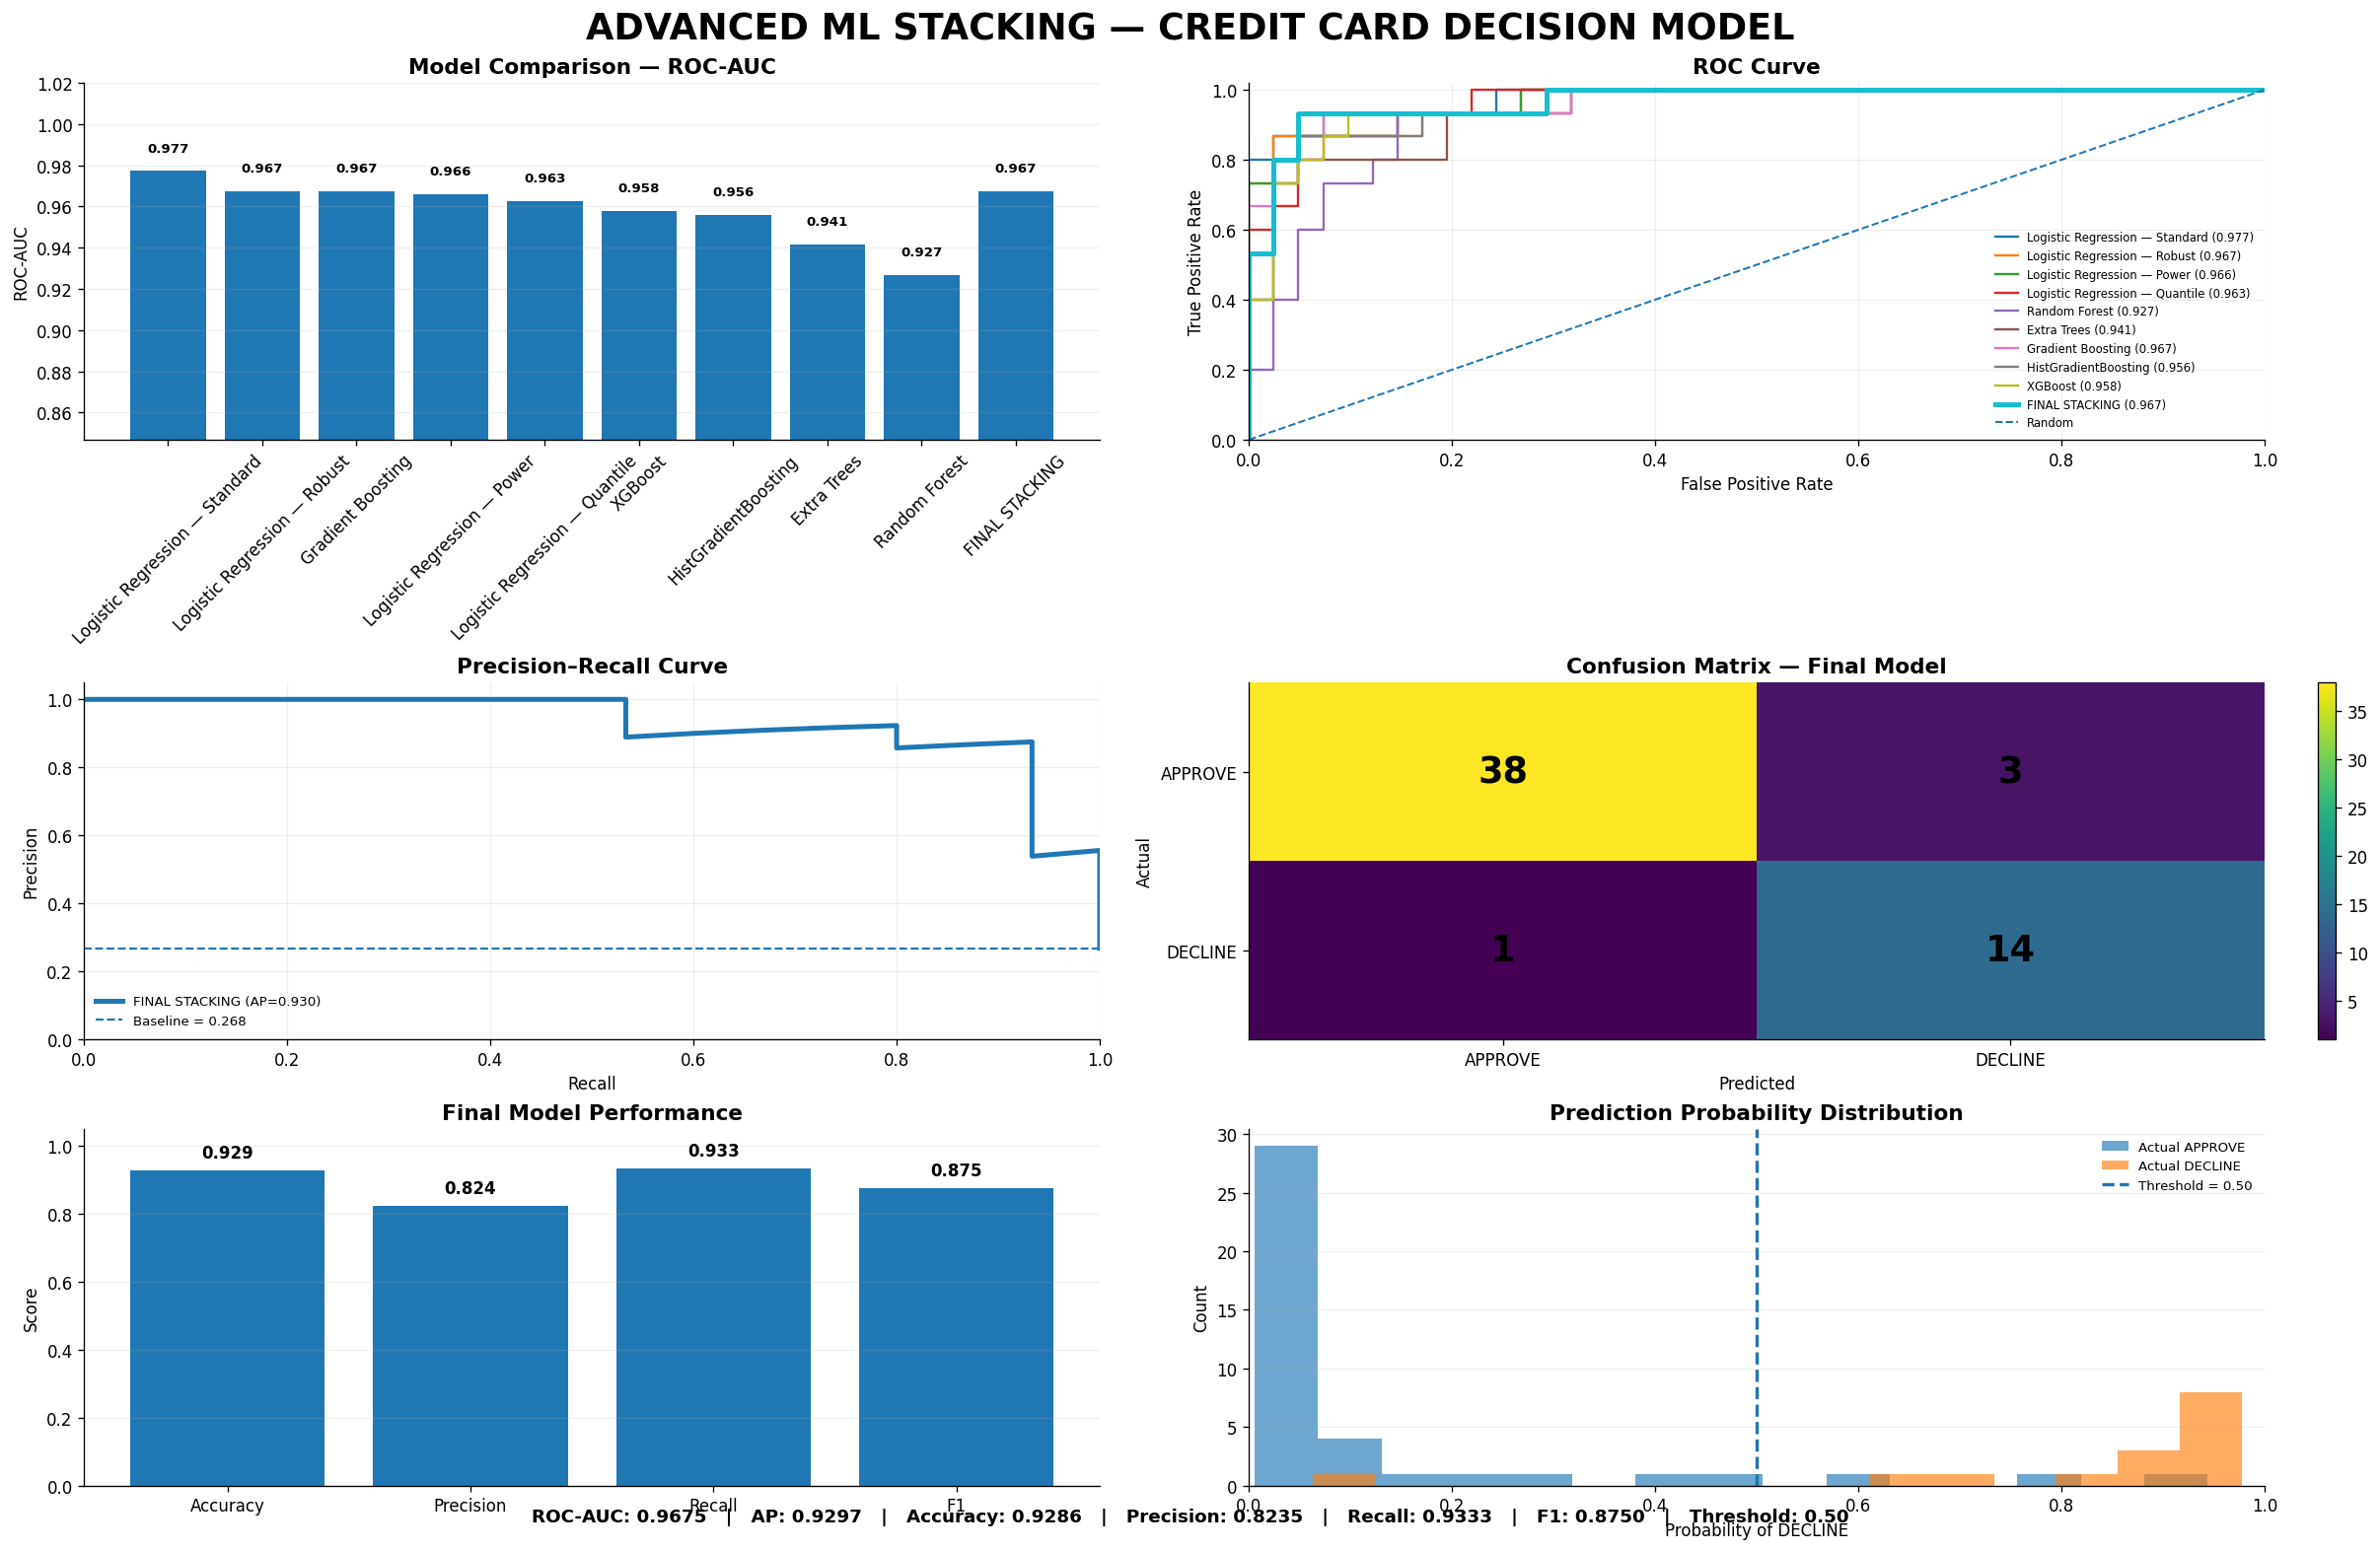


STATIC DASHBOARD SAVED
Dashboard: /content/ADVANCED_ML_STATIC_DASHBOARD.png


In [ ]:
# ================================================================
# 27. STATIC ALL-IN-ONE DASHBOARD
# ================================================================
#
# ALL GRAPHS ARE COMBINED INTO ONE IMAGE
#
# ax1 = Model Comparison
# ax2 = ROC Curve
# ax3 = Precision-Recall Curve
# ax4 = Confusion Matrix
# ax5 = Final Performance
# ax6 = Probability Distribution
#
# ONE STATIC DASHBOARD IMAGE
# ================================================================


# ================================================================
# VISUAL STYLE
# ================================================================

plt.rcParams.update({

    "figure.dpi": 120,
    "savefig.dpi": 200,

    "font.size": 10,

    "axes.titlesize": 13,
    "axes.labelsize": 10,

    "axes.titleweight": "bold",

    "axes.spines.top": False,
    "axes.spines.right": False,

    "legend.fontsize": 8

})


# ================================================================
# PREPARE MODEL DATA
# ================================================================

plot_df = model_results_df.copy()


# Add final stacking model

plot_df.loc[len(plot_df)] = {

    "Model": "FINAL STACKING",

    "ROC-AUC": auc,

    "Average Precision": ap,

    "Accuracy": accuracy,

    "F1": f1

}


# ================================================================
# CREATE ONE STATIC DASHBOARD
# ================================================================

fig = plt.figure(

    figsize=(20, 13),

    constrained_layout=True

)


# ================================================================
# GRID
# ================================================================
#
# 3 rows x 2 columns
#
# ax1 -> Model Comparison
# ax2 -> ROC
# ax3 -> Precision Recall
# ax4 -> Confusion Matrix
# ax5 -> Performance
# ax6 -> Probability Distribution
#
# ================================================================


ax1 = fig.add_subplot(3, 2, 1)

ax2 = fig.add_subplot(3, 2, 2)

ax3 = fig.add_subplot(3, 2, 3)

ax4 = fig.add_subplot(3, 2, 4)

ax5 = fig.add_subplot(3, 2, 5)

ax6 = fig.add_subplot(3, 2, 6)


# ================================================================
# MAIN DASHBOARD TITLE
# ================================================================

fig.suptitle(

    "ADVANCED ML STACKING — CREDIT CARD DECISION MODEL",

    fontsize=22,

    fontweight="bold"

)


# ================================================================
# AX1 — MODEL COMPARISON
# ================================================================

bars = ax1.bar(

    plot_df["Model"],

    plot_df["ROC-AUC"]

)


ax1.set_title(

    "Model Comparison — ROC-AUC"

)


ax1.set_ylabel(

    "ROC-AUC"

)


ax1.set_ylim(

    max(

        0,

        plot_df["ROC-AUC"].min() - 0.08

    ),

    1.02

)


ax1.tick_params(

    axis="x",

    rotation=45

)


ax1.grid(

    axis="y",

    alpha=0.20

)


for bar, value in zip(

    bars,

    plot_df["ROC-AUC"]

):

    ax1.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.008,

        f"{value:.3f}",

        ha="center",

        va="bottom",

        fontsize=8,

        fontweight="bold"

    )


# ================================================================
# AX2 — ROC CURVE
# ================================================================

for name in model_names:

    probability = test_predictions[name]


    fpr, tpr, _ = roc_curve(

        y_test,

        probability

    )


    model_auc = roc_auc_score(

        y_test,

        probability

    )


    ax2.plot(

        fpr,

        tpr,

        linewidth=1.4,

        label=f"{name} ({model_auc:.3f})"

    )


# Final stacking ROC

fpr_final, tpr_final, _ = roc_curve(

    y_test,

    final_probability

)


ax2.plot(

    fpr_final,

    tpr_final,

    linewidth=3,

    label=f"FINAL STACKING ({auc:.3f})"

)


# Random baseline

ax2.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    linewidth=1.2,

    label="Random"

)


ax2.set_title(

    "ROC Curve"

)


ax2.set_xlabel(

    "False Positive Rate"

)


ax2.set_ylabel(

    "True Positive Rate"

)


ax2.set_xlim(

    0,

    1

)


ax2.set_ylim(

    0,

    1.02

)


ax2.legend(

    frameon=False,

    fontsize=7,

    loc="lower right"

)


ax2.grid(

    alpha=0.20

)


# ================================================================
# AX3 — PRECISION RECALL CURVE
# ================================================================

precision_curve, recall_curve, _ = (

    precision_recall_curve(

        y_test,

        final_probability

    )

)


ax3.plot(

    recall_curve,

    precision_curve,

    linewidth=3,

    label=f"FINAL STACKING (AP={ap:.3f})"

)


# Baseline

ax3.axhline(

    y=y_test.mean(),

    linestyle="--",

    linewidth=1.3,

    label=f"Baseline = {y_test.mean():.3f}"

)


ax3.set_title(

    "Precision–Recall Curve"

)


ax3.set_xlabel(

    "Recall"

)


ax3.set_ylabel(

    "Precision"

)


ax3.set_xlim(

    0,

    1

)


ax3.set_ylim(

    0,

    1.05

)


ax3.legend(

    frameon=False

)


ax3.grid(

    alpha=0.20

)


# ================================================================
# AX4 — CONFUSION MATRIX
# ================================================================

im = ax4.imshow(

    cm,

    interpolation="nearest",

    aspect="auto"

)


ax4.set_title(

    "Confusion Matrix — Final Model"

)


ax4.set_xlabel(

    "Predicted"

)


ax4.set_ylabel(

    "Actual"

)


ax4.set_xticks([0, 1])

ax4.set_yticks([0, 1])


ax4.set_xticklabels([

    "APPROVE",

    "DECLINE"

])


ax4.set_yticklabels([

    "APPROVE",

    "DECLINE"

])


# Write values inside matrix

for i in range(2):

    for j in range(2):

        ax4.text(

            j,

            i,

            str(cm[i, j]),

            ha="center",

            va="center",

            fontsize=22,

            fontweight="bold"

        )


fig.colorbar(

    im,

    ax=ax4,

    fraction=0.046,

    pad=0.04

)


# ================================================================
# AX5 — FINAL PERFORMANCE
# ================================================================

metric_names = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1"

]


metric_values = [

    accuracy,

    precision,

    recall,

    f1

]


bars = ax5.bar(

    metric_names,

    metric_values

)


ax5.set_title(

    "Final Model Performance"

)


ax5.set_ylabel(

    "Score"

)


ax5.set_ylim(

    0,

    1.05

)


ax5.grid(

    axis="y",

    alpha=0.20

)


for bar, value in zip(

    bars,

    metric_values

):

    ax5.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.025,

        f"{value:.3f}",

        ha="center",

        va="bottom",

        fontsize=10,

        fontweight="bold"

    )


# ================================================================
# AX6 — PROBABILITY DISTRIBUTION
# ================================================================

approve_probs = final_probability[

    y_test.values == 0

]


decline_probs = final_probability[

    y_test.values == 1

]


ax6.hist(

    approve_probs,

    bins=15,

    alpha=0.65,

    label="Actual APPROVE"

)


ax6.hist(

    decline_probs,

    bins=15,

    alpha=0.65,

    label="Actual DECLINE"

)


ax6.axvline(

    THRESHOLD,

    linestyle="--",

    linewidth=2,

    label=f"Threshold = {THRESHOLD:.2f}"

)


ax6.set_title(

    "Prediction Probability Distribution"

)


ax6.set_xlabel(

    "Probability of DECLINE"

)


ax6.set_ylabel(

    "Count"

)


ax6.set_xlim(

    0,

    1

)


ax6.legend(

    frameon=False

)


ax6.grid(

    axis="y",

    alpha=0.20

)


# ================================================================
# DASHBOARD FOOTER
# ================================================================

fig.text(

    0.50,

    0.015,

    (
        f"ROC-AUC: {auc:.4f}   |   "
        f"AP: {ap:.4f}   |   "
        f"Accuracy: {accuracy:.4f}   |   "
        f"Precision: {precision:.4f}   |   "
        f"Recall: {recall:.4f}   |   "
        f"F1: {f1:.4f}   |   "
        f"Threshold: {THRESHOLD:.2f}"
    ),

    ha="center",

    fontsize=11,

    fontweight="bold"

)


# ================================================================
# SAVE DASHBOARD
# ================================================================

DASHBOARD_OUTPUT = (

    "/content/"

    "ADVANCED_ML_STATIC_DASHBOARD.png"

)


fig.savefig(

    DASHBOARD_OUTPUT,

    dpi=200,

    bbox_inches="tight"

)


# ================================================================
# SHOW FINAL DASHBOARD
# ================================================================

plt.show()


print("\n" + "=" * 75)

print("STATIC DASHBOARD SAVED")

print("=" * 75)

print(

    "Dashboard:",

    DASHBOARD_OUTPUT

)

DATA
Shape: (280, 13)

Target distribution:
decision
0    207
1     73
Name: count, dtype: int64

ML FEATURES:
['account_age_days', 'account_balance', 'amount', 'beneficiaries', 'channel', 'linked_cards', 'months_active', 'recent_chargebacks', 'trust_score', 'utilisation']

Train: 224
Test : 56

PROCESSED FEATURES
TensorFlow input dimensions: 13
 0 -> numeric__account_age_days
 1 -> numeric__account_balance
 2 -> numeric__amount
 3 -> numeric__beneficiaries
 4 -> numeric__linked_cards
 5 -> numeric__months_active
 6 -> numeric__recent_chargebacks
 7 -> numeric__trust_score
 8 -> numeric__utilisation
 9 -> categorical__channel_A
10 -> categorical__channel_B
11 -> categorical__channel_C
12 -> categorical__channel_D

AFTER SMOTE
decision
0    166
1    166
Name: count, dtype: int64

Before SMOTE: (224, 13)
After SMOTE : (332, 13)

MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 192 (768.00 B)


TRAINING TENSORFLOW MODEL
Epoch 1/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.6170 - auc: 0.6312 - loss: 0.7332 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.5266 - learning_rate: 0.0010
Epoch 2/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8121 - auc: 0.8803 - loss: 0.4697 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.4853 - learning_rate: 0.0010
Epoch 3/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8582 - auc: 0.9375 - loss: 0.3598 - val_accuracy: 0.9600 - val_auc: 0.0000e+00 - val_loss: 0.4542 - learning_rate: 0.0010
Epoch 4/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8830 - auc: 0.9489 - loss: 0.3067 - val_accuracy: 0.9400 - val_auc: 0.0000e+00 - val_loss: 0.4392 - learning_rate: 0.0010
Epoch 5/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9149 - auc: 0.9753 - loss: 0.2463 - val_accuracy: 0.9200 - val_auc: 0.0000e+00 - val_loss: 0.4115 - learning_rate: 0.0010
Epoch 6/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 


FINAL TENSORFLOW RESULTS

ROC-AUC:           0.9675
Average Precision: 0.9344
Accuracy:          0.9107
Precision DECLINE: 0.8571
Recall DECLINE:    0.8000
F1 DECLINE:        0.8276
Threshold:         0.50

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     APPROVE     0.9286    0.9512    0.9398        41
     DECLINE     0.8571    0.8000    0.8276        15

    accuracy                         0.9107        56
   macro avg     0.8929    0.8756    0.8837        56
weighted avg     0.9094    0.9107    0.9097        56


CONFUSION MATRIX
[[39  2]
 [ 3 12]]

True Negatives : 39
False Positives: 2
False Negatives: 3
True Positives : 12


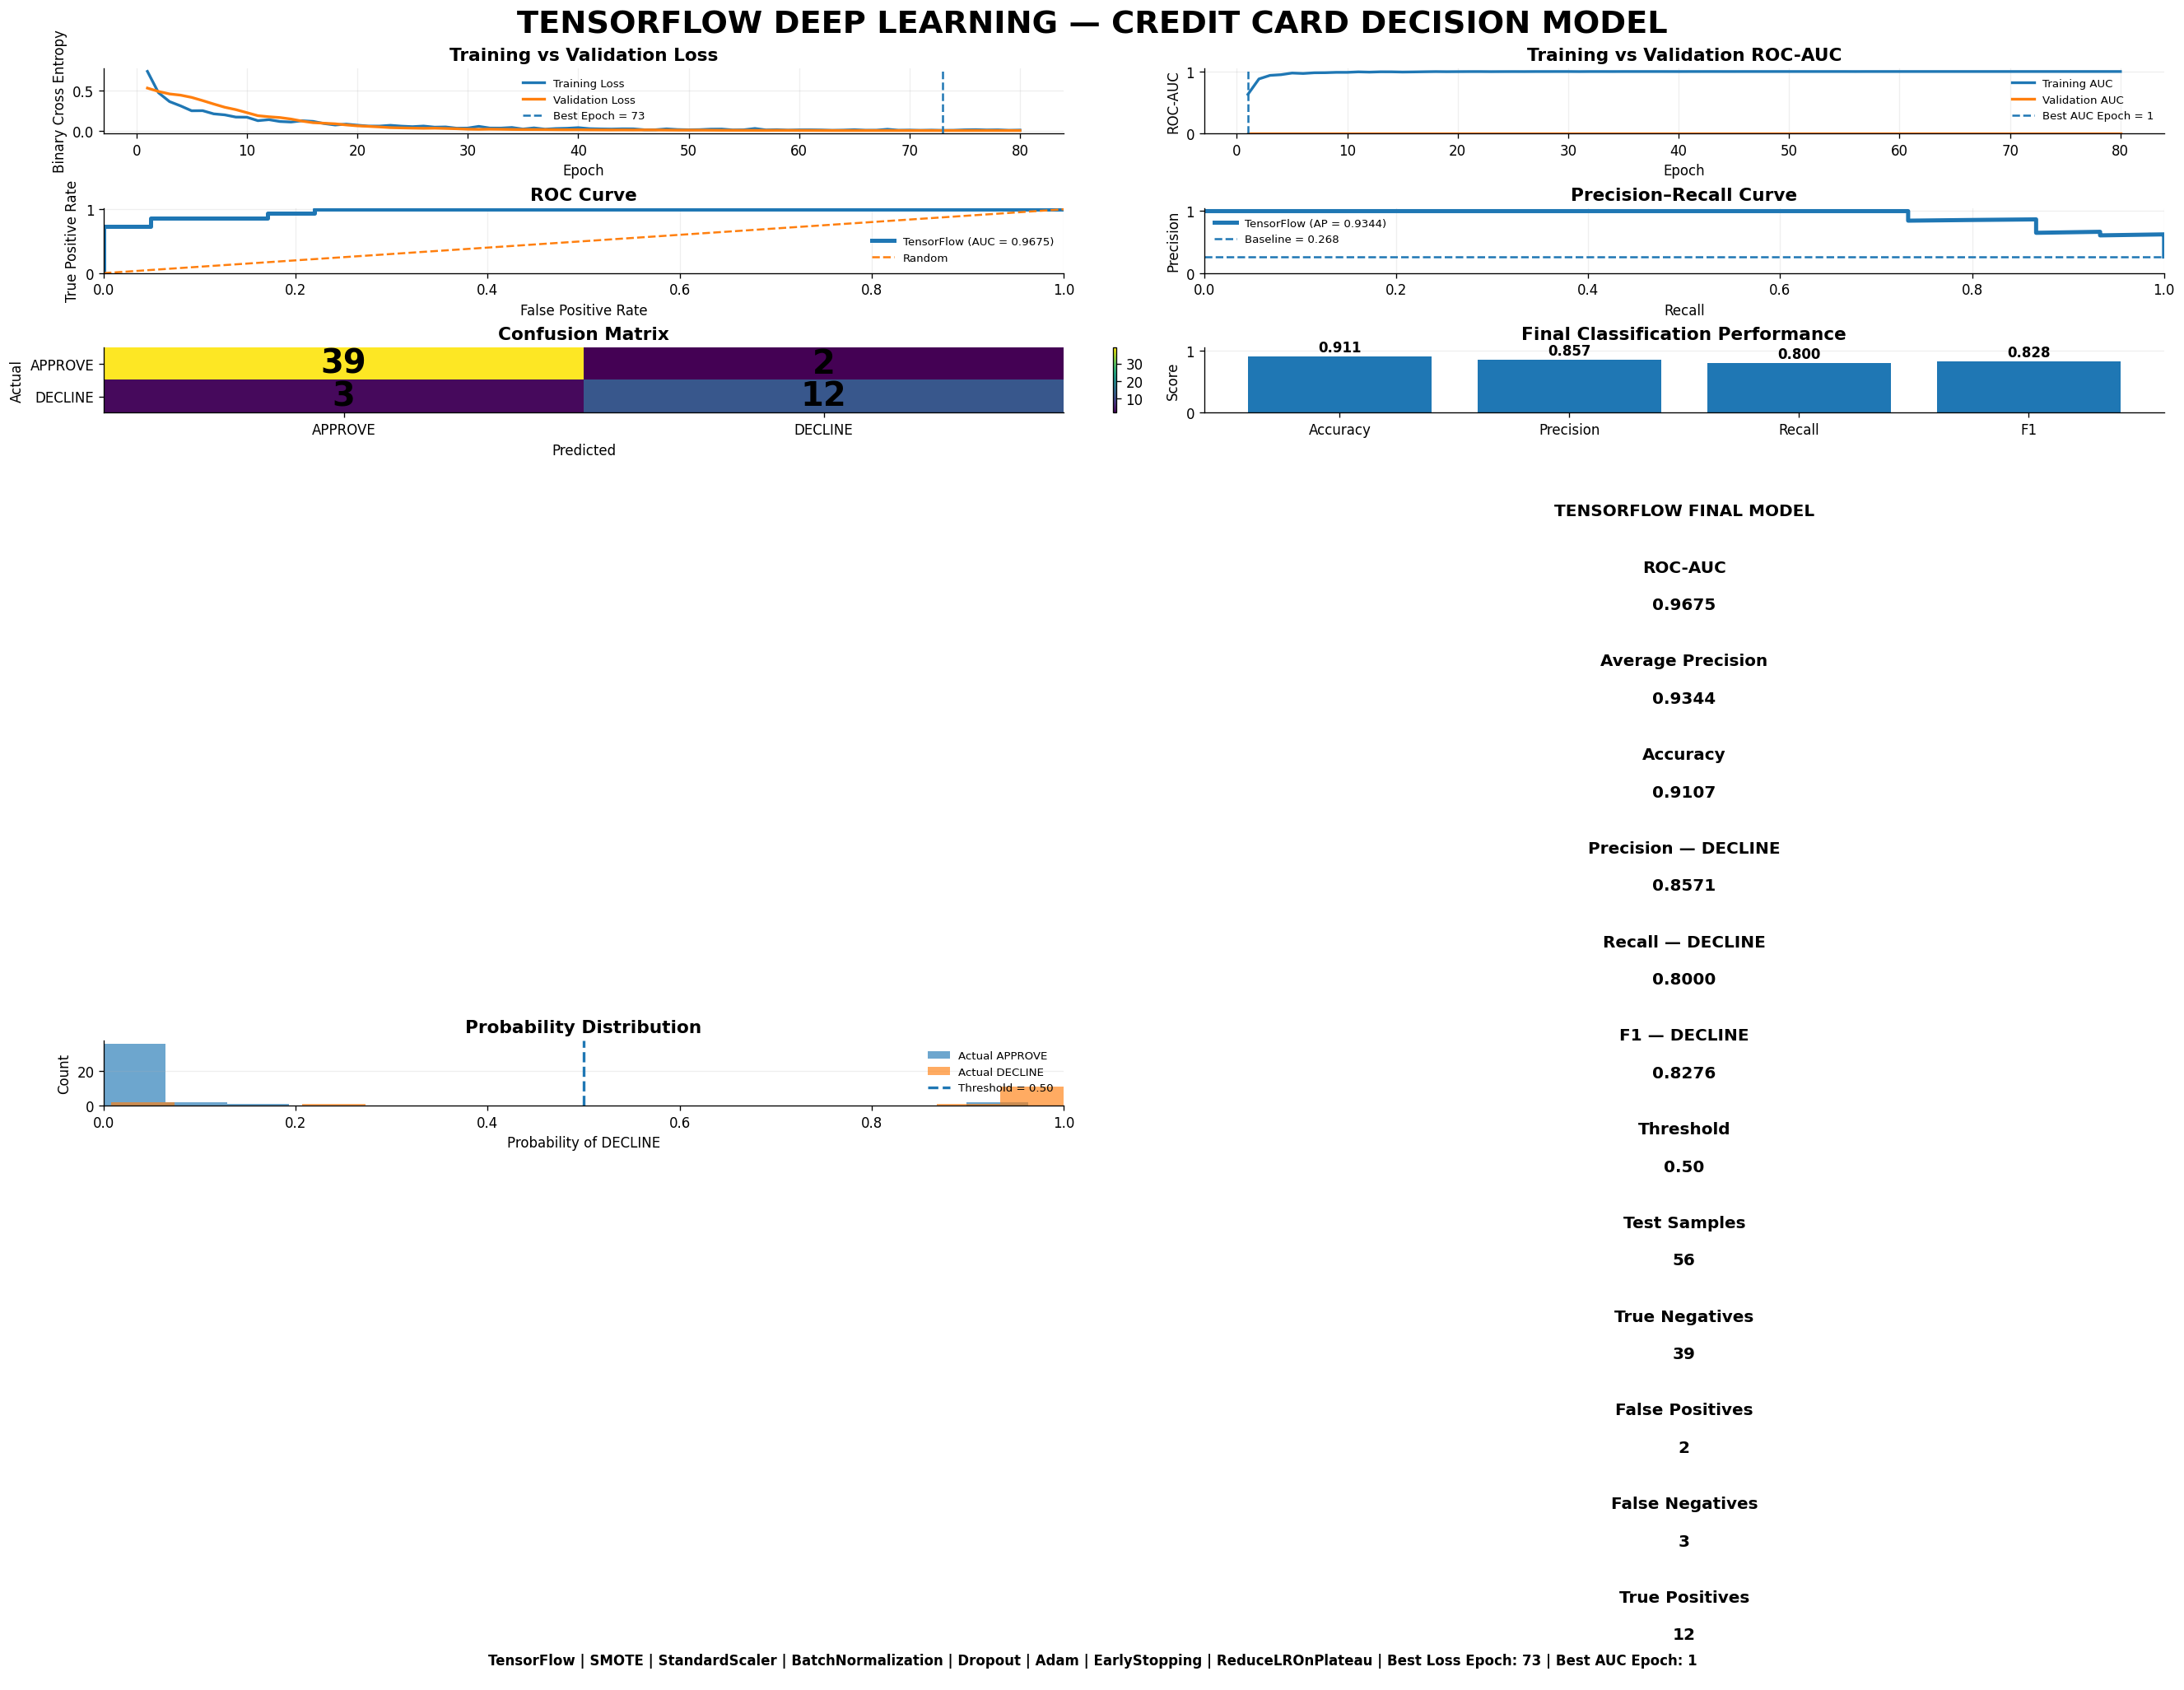


DONE

Static Dashboard: /content/TENSORFLOW_STATIC_DASHBOARD.png
Predictions: /content/TENSORFLOW_FINAL_RESULTS.csv
Summary: /content/TENSORFLOW_FINAL_SUMMARY.csv
Confusion Matrix: /content/TENSORFLOW_CONFUSION_MATRIX.csv

FINAL METRICS
ROC-AUC:           0.9675
Average Precision: 0.9344
Accuracy:          0.9107
Precision DECLINE: 0.8571
Recall DECLINE:    0.8000
F1 DECLINE:        0.8276
Threshold:         0.50
Best Loss Epoch:   73
Best AUC Epoch:    1
Epochs Trained:    80
Test Samples:      56

CONFUSION MATRIX
[[39  2]
 [ 3 12]]

FILES CREATED
1. /content/TENSORFLOW_STATIC_DASHBOARD.png
2. /content/TENSORFLOW_FINAL_RESULTS.csv
3. /content/TENSORFLOW_FINAL_SUMMARY.csv
4. /content/TENSORFLOW_CONFUSION_MATRIX.csv


In [ ]:
# ================================================================
# FAST TENSORFLOW DEEP LEARNING MODEL
#
# NO OOF
# NO NESTED CV
# NO COSINE
# NO LOGISTIC REGRESSION
# TRAIN ONCE
#
# SMOTE
# STANDARD SCALER
# ONE-HOT ENCODING
#
# MODEL:
#   Dense 64
#   BatchNormalization
#   Dropout
#   Dense 32
#   BatchNormalization
#   Dropout
#   Dense 16
#   Dense 1
#
# FINAL:
#   ONE STATIC DASHBOARD IMAGE
#
# ALL GRAPHS:
#   ax1 -> Training / Validation Loss
#   ax2 -> Training / Validation AUC
#   ax3 -> ROC Curve
#   ax4 -> Precision-Recall Curve
#   ax5 -> Confusion Matrix
#   ax6 -> Final Performance
#   ax7 -> Probability Distribution
#   ax8 -> Metric Summary
# ================================================================


# ================================================================
# 1. IMPORTS
# ================================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE


# ================================================================
# 2. WARNINGS
# ================================================================

warnings.filterwarnings("ignore")


# ================================================================
# 3. SEED
# ================================================================

SEED = 42

np.random.seed(SEED)

random.seed(SEED)

tf.random.set_seed(SEED)


# ================================================================
# 4. LOAD DATA
# ================================================================

FILE = "/content/R1_R2_ALL_UNIQUE_ORDERED_v2.csv"

df = pd.read_csv(FILE).copy()


print("=" * 75)
print("DATA")
print("=" * 75)

print("Shape:", df.shape)


# ================================================================
# 5. TARGET
# ================================================================

if df["decision"].dtype == "object":

    df["decision"] = (

        df["decision"]
        .astype(str)
        .str.strip()
        .str.upper()
        .map({
            "APPROVE": 0,
            "DECLINE": 1
        })

    )

else:

    df["decision"] = pd.to_numeric(
        df["decision"],
        errors="coerce"
    )


if df["decision"].isna().any():

    raise ValueError(
        "Target contains invalid / missing values."
    )


df["decision"] = df["decision"].astype(int)

y = df["decision"]


print("\nTarget distribution:")

print(
    y.value_counts()
)


# ================================================================
# 6. FEATURES
# ================================================================

X = df.drop(

    columns=[

        "id",

        "score",

        "decision"

    ],

    errors="ignore"

)


numeric_features = [

    "account_age_days",

    "account_balance",

    "amount",

    "beneficiaries",

    "linked_cards",

    "months_active",

    "recent_chargebacks",

    "trust_score",

    "utilisation"

]


categorical_features = [

    "channel"

]


print("\nML FEATURES:")

print(
    X.columns.tolist()
)


# ================================================================
# 7. TRAIN / TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=SEED

)


print("\nTrain:", len(X_train))

print("Test :", len(X_test))


# ================================================================
# 8. ONE-HOT ENCODER
# ================================================================

try:

    ohe = OneHotEncoder(

        handle_unknown="ignore",

        sparse_output=False

    )

except TypeError:

    ohe = OneHotEncoder(

        handle_unknown="ignore",

        sparse=False

    )


# ================================================================
# 9. NUMERIC PIPELINE
# ================================================================

numeric_pipe = Pipeline([

    (

        "imputer",

        SimpleImputer(

            strategy="median"

        )

    ),

    (

        "scaler",

        StandardScaler()

    )

])


# ================================================================
# 10. CATEGORICAL PIPELINE
# ================================================================

categorical_pipe = Pipeline([

    (

        "imputer",

        SimpleImputer(

            strategy="most_frequent"

        )

    ),

    (

        "onehot",

        ohe

    )

])


# ================================================================
# 11. COMPLETE PREPROCESSOR
# ================================================================

preprocessor = ColumnTransformer([

    (

        "numeric",

        numeric_pipe,

        numeric_features

    ),

    (

        "categorical",

        categorical_pipe,

        categorical_features

    )

])


# ================================================================
# 12. PREPROCESS DATA
# ================================================================
#
# IMPORTANT:
#
# Fit ONLY on training data.
#
# Test data is only transformed.
#
# This prevents preprocessing leakage.
# ================================================================

X_train_processed = (

    preprocessor.fit_transform(

        X_train

    )

)


X_test_processed = (

    preprocessor.transform(

        X_test

    )

)


# ================================================================
# 13. SHOW PROCESSED FEATURES
# ================================================================

feature_names = (

    preprocessor
    .get_feature_names_out()

)


print("\n" + "=" * 75)

print("PROCESSED FEATURES")

print("=" * 75)


print(

    "TensorFlow input dimensions:",

    len(feature_names)

)


for i, feature in enumerate(

    feature_names

):

    print(

        f"{i:2d} -> {feature}"

    )


# ================================================================
# 14. SMOTE
# ================================================================
#
# SMOTE is applied ONLY to training data.
#
# Test data remains completely untouched.
# ================================================================

smote = SMOTE(

    random_state=SEED,

    k_neighbors=5

)


X_train_smote, y_train_smote = (

    smote.fit_resample(

        X_train_processed,

        y_train

    )

)


print("\n" + "=" * 75)

print("AFTER SMOTE")

print("=" * 75)


print(

    pd.Series(

        y_train_smote

    ).value_counts()

)


print(

    "\nBefore SMOTE:",

    X_train_processed.shape

)


print(

    "After SMOTE :",

    X_train_smote.shape

)


# ================================================================
# 15. CLEAR PREVIOUS TENSORFLOW SESSION
# ================================================================

tf.keras.backend.clear_session()


# ================================================================
# 16. TENSORFLOW MODEL
# ================================================================

nn = tf.keras.Sequential([


    # ------------------------------------------------------------
    # INPUT
    # ------------------------------------------------------------

    tf.keras.layers.Input(

        shape=(

            X_train_smote.shape[1],

        )

    ),


    # ------------------------------------------------------------
    # FIRST HIDDEN LAYER
    # ------------------------------------------------------------

    tf.keras.layers.Dense(

        64,

        activation="relu"

    ),


    # ------------------------------------------------------------
    # BATCH NORMALIZATION
    # ------------------------------------------------------------

    tf.keras.layers.BatchNormalization(),


    # ------------------------------------------------------------
    # DROPOUT
    # ------------------------------------------------------------

    tf.keras.layers.Dropout(

        0.20

    ),


    # ------------------------------------------------------------
    # SECOND HIDDEN LAYER
    # ------------------------------------------------------------

    tf.keras.layers.Dense(

        32,

        activation="relu"

    ),


    # ------------------------------------------------------------
    # BATCH NORMALIZATION
    # ------------------------------------------------------------

    tf.keras.layers.BatchNormalization(),


    # ------------------------------------------------------------
    # DROPOUT
    # ------------------------------------------------------------

    tf.keras.layers.Dropout(

        0.15

    ),


    # ------------------------------------------------------------
    # THIRD HIDDEN LAYER
    # ------------------------------------------------------------

    tf.keras.layers.Dense(

        16,

        activation="relu"

    ),


    # ------------------------------------------------------------
    # OUTPUT
    # ------------------------------------------------------------

    tf.keras.layers.Dense(

        1,

        activation="sigmoid"

    )

])


# ================================================================
# 17. COMPILE
# ================================================================

nn.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=0.001

    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.AUC(

            name="auc"

        )

    ]

)


# ================================================================
# 18. MODEL ARCHITECTURE
# ================================================================

print("\n" + "=" * 75)

print("MODEL ARCHITECTURE")

print("=" * 75)


nn.summary()


# ================================================================
# 19. CALLBACKS
# ================================================================

early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True,

    verbose=1

)


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=4,

    min_lr=1e-5,

    verbose=1

)


# ================================================================
# 20. TRAINING
# ================================================================

print("\n" + "=" * 75)

print("TRAINING TENSORFLOW MODEL")

print("=" * 75)


history = nn.fit(

    X_train_smote,

    y_train_smote,

    validation_split=0.15,

    epochs=80,

    batch_size=16,

    callbacks=[

        early_stop,

        reduce_lr

    ],

    verbose=1

)


# ================================================================
# 21. BEST EPOCH
# ================================================================

best_epoch_loss = (

    np.argmin(

        history.history["val_loss"]

    ) + 1

)


best_epoch_auc = (

    np.argmax(

        history.history["val_auc"]

    ) + 1

)


print("\n" + "=" * 75)

print("TRAINING SUMMARY")

print("=" * 75)


print(

    "Total epochs trained:",

    len(

        history.history["loss"]

    )

)


print(

    "Best validation-loss epoch:",

    best_epoch_loss

)


print(

    "Best validation-AUC epoch:",

    best_epoch_auc

)


# ================================================================
# 22. TEST PREDICTIONS
# ================================================================

nn_probability = nn.predict(

    X_test_processed,

    verbose=0

).ravel()


# ================================================================
# 23. FINAL THRESHOLD
# ================================================================

THRESHOLD = 0.50


final_prediction = (

    nn_probability >= THRESHOLD

).astype(int)


# ================================================================
# 24. METRICS
# ================================================================

accuracy = accuracy_score(

    y_test,

    final_prediction

)


precision = precision_score(

    y_test,

    final_prediction,

    zero_division=0

)


recall = recall_score(

    y_test,

    final_prediction,

    zero_division=0

)


f1 = f1_score(

    y_test,

    final_prediction,

    zero_division=0

)


auc = roc_auc_score(

    y_test,

    nn_probability

)


ap = average_precision_score(

    y_test,

    nn_probability

)


# ================================================================
# 25. FINAL RESULTS
# ================================================================

print("\n" + "=" * 75)

print("FINAL TENSORFLOW RESULTS")

print("=" * 75)


print(

    f"\nROC-AUC:           {auc:.4f}"

)


print(

    f"Average Precision: {ap:.4f}"

)


print(

    f"Accuracy:          {accuracy:.4f}"

)


print(

    f"Precision DECLINE: {precision:.4f}"

)


print(

    f"Recall DECLINE:    {recall:.4f}"

)


print(

    f"F1 DECLINE:        {f1:.4f}"

)


print(

    f"Threshold:         {THRESHOLD:.2f}"

)


# ================================================================
# 26. CLASSIFICATION REPORT
# ================================================================

print("\n" + "=" * 75)

print("CLASSIFICATION REPORT")

print("=" * 75)


print(

    classification_report(

        y_test,

        final_prediction,

        target_names=[

            "APPROVE",

            "DECLINE"

        ],

        digits=4,

        zero_division=0

    )

)


# ================================================================
# 27. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(

    y_test,

    final_prediction

)


tn, fp, fn, tp = cm.ravel()


print("\n" + "=" * 75)

print("CONFUSION MATRIX")

print("=" * 75)


print(cm)


print("\nTrue Negatives :", tn)

print("False Positives:", fp)

print("False Negatives:", fn)

print("True Positives :", tp)


# ================================================================
# 28. ROC CURVE DATA
# ================================================================

fpr, tpr, roc_thresholds = roc_curve(

    y_test,

    nn_probability

)


# ================================================================
# 29. PRECISION-RECALL CURVE DATA
# ================================================================

pr_precision, pr_recall, pr_thresholds = (

    precision_recall_curve(

        y_test,

        nn_probability

    )

)


# ================================================================
# 30. PROBABILITY GROUPS
# ================================================================

approve_probs = nn_probability[

    y_test.values == 0

]


decline_probs = nn_probability[

    y_test.values == 1

]


# ================================================================
# 31. VISUAL STYLE
# ================================================================

plt.rcParams.update({

    "figure.dpi": 120,

    "savefig.dpi": 200,

    "font.size": 10,

    "axes.titlesize": 13,

    "axes.labelsize": 10,

    "axes.titleweight": "bold",

    "axes.spines.top": False,

    "axes.spines.right": False,

    "legend.fontsize": 8

})


# ================================================================
# 32. CREATE STATIC DASHBOARD
# ================================================================
#
# EVERYTHING IS INSIDE ONE FIGURE.
#
# ax1
# ax2
# ax3
# ax4
# ax5
# ax6
# ax7
# ax8
#
# ================================================================

fig = plt.figure(

    figsize=(22, 17),

    constrained_layout=True

)


# ================================================================
# CREATE AXES
# ================================================================

ax1 = fig.add_subplot(4, 2, 1)

ax2 = fig.add_subplot(4, 2, 2)

ax3 = fig.add_subplot(4, 2, 3)

ax4 = fig.add_subplot(4, 2, 4)

ax5 = fig.add_subplot(4, 2, 5)

ax6 = fig.add_subplot(4, 2, 6)

ax7 = fig.add_subplot(4, 2, 7)

ax8 = fig.add_subplot(4, 2, 8)


# ================================================================
# MAIN TITLE
# ================================================================

fig.suptitle(

    "TENSORFLOW DEEP LEARNING — CREDIT CARD DECISION MODEL",

    fontsize=23,

    fontweight="bold"

)


# ================================================================
# AX1 — TRAINING / VALIDATION LOSS
# ================================================================

epochs = range(

    1,

    len(

        history.history["loss"]

    ) + 1

)


ax1.plot(

    epochs,

    history.history["loss"],

    linewidth=2,

    label="Training Loss"

)


ax1.plot(

    epochs,

    history.history["val_loss"],

    linewidth=2,

    label="Validation Loss"

)


ax1.axvline(

    best_epoch_loss,

    linestyle="--",

    linewidth=1.5,

    label=f"Best Epoch = {best_epoch_loss}"

)


ax1.set_title(

    "Training vs Validation Loss"

)


ax1.set_xlabel(

    "Epoch"

)


ax1.set_ylabel(

    "Binary Cross Entropy"

)


ax1.legend(

    frameon=False

)


ax1.grid(

    alpha=0.20

)


# ================================================================
# AX2 — TRAINING / VALIDATION AUC
# ================================================================

ax2.plot(

    epochs,

    history.history["auc"],

    linewidth=2,

    label="Training AUC"

)


ax2.plot(

    epochs,

    history.history["val_auc"],

    linewidth=2,

    label="Validation AUC"

)


ax2.axvline(

    best_epoch_auc,

    linestyle="--",

    linewidth=1.5,

    label=f"Best AUC Epoch = {best_epoch_auc}"

)


ax2.set_title(

    "Training vs Validation ROC-AUC"

)


ax2.set_xlabel(

    "Epoch"

)


ax2.set_ylabel(

    "ROC-AUC"

)


ax2.set_ylim(

    0,

    1.05

)


ax2.legend(

    frameon=False

)


ax2.grid(

    alpha=0.20

)


# ================================================================
# AX3 — ROC CURVE
# ================================================================

ax3.plot(

    fpr,

    tpr,

    linewidth=3,

    label=f"TensorFlow (AUC = {auc:.4f})"

)


ax3.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    linewidth=1.5,

    label="Random"

)


ax3.set_title(

    "ROC Curve"

)


ax3.set_xlabel(

    "False Positive Rate"

)


ax3.set_ylabel(

    "True Positive Rate"

)


ax3.set_xlim(

    0,

    1

)


ax3.set_ylim(

    0,

    1.02

)


ax3.legend(

    frameon=False,

    loc="lower right"

)


ax3.grid(

    alpha=0.20

)


# ================================================================
# AX4 — PRECISION-RECALL CURVE
# ================================================================

ax4.plot(

    pr_recall,

    pr_precision,

    linewidth=3,

    label=f"TensorFlow (AP = {ap:.4f})"

)


ax4.axhline(

    y=y_test.mean(),

    linestyle="--",

    linewidth=1.5,

    label=f"Baseline = {y_test.mean():.3f}"

)


ax4.set_title(

    "Precision–Recall Curve"

)


ax4.set_xlabel(

    "Recall"

)


ax4.set_ylabel(

    "Precision"

)


ax4.set_xlim(

    0,

    1

)


ax4.set_ylim(

    0,

    1.05

)


ax4.legend(

    frameon=False

)


ax4.grid(

    alpha=0.20

)


# ================================================================
# AX5 — CONFUSION MATRIX
# ================================================================

im = ax5.imshow(

    cm,

    interpolation="nearest",

    aspect="auto"

)


ax5.set_title(

    "Confusion Matrix"

)


ax5.set_xlabel(

    "Predicted"

)


ax5.set_ylabel(

    "Actual"

)


ax5.set_xticks([0, 1])

ax5.set_yticks([0, 1])


ax5.set_xticklabels([

    "APPROVE",

    "DECLINE"

])


ax5.set_yticklabels([

    "APPROVE",

    "DECLINE"

])


for i in range(2):

    for j in range(2):

        ax5.text(

            j,

            i,

            str(cm[i, j]),

            ha="center",

            va="center",

            fontsize=24,

            fontweight="bold"

        )


fig.colorbar(

    im,

    ax=ax5,

    fraction=0.046,

    pad=0.04

)


# ================================================================
# AX6 — FINAL PERFORMANCE
# ================================================================

metric_names = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1"

]


metric_values = [

    accuracy,

    precision,

    recall,

    f1

]


bars = ax6.bar(

    metric_names,

    metric_values

)


ax6.set_title(

    "Final Classification Performance"

)


ax6.set_ylabel(

    "Score"

)


ax6.set_ylim(

    0,

    1.05

)


ax6.grid(

    axis="y",

    alpha=0.20

)


for bar, value in zip(

    bars,

    metric_values

):

    ax6.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.025,

        f"{value:.3f}",

        ha="center",

        va="bottom",

        fontweight="bold"

    )


# ================================================================
# AX7 — PROBABILITY DISTRIBUTION
# ================================================================

ax7.hist(

    approve_probs,

    bins=15,

    alpha=0.65,

    label="Actual APPROVE"

)


ax7.hist(

    decline_probs,

    bins=15,

    alpha=0.65,

    label="Actual DECLINE"

)


ax7.axvline(

    THRESHOLD,

    linestyle="--",

    linewidth=2,

    label=f"Threshold = {THRESHOLD:.2f}"

)


ax7.set_title(

    "Probability Distribution"

)


ax7.set_xlabel(

    "Probability of DECLINE"

)


ax7.set_ylabel(

    "Count"

)


ax7.set_xlim(

    0,

    1

)


ax7.legend(

    frameon=False

)


ax7.grid(

    axis="y",

    alpha=0.20

)


# ================================================================
# AX8 — METRIC SUMMARY
# ================================================================

ax8.axis("off")


summary_text = f"""

TENSORFLOW FINAL MODEL


ROC-AUC

{auc:.4f}


Average Precision

{ap:.4f}


Accuracy

{accuracy:.4f}


Precision — DECLINE

{precision:.4f}


Recall — DECLINE

{recall:.4f}


F1 — DECLINE

{f1:.4f}


Threshold

{THRESHOLD:.2f}


Test Samples

{len(y_test)}


True Negatives

{tn}


False Positives

{fp}


False Negatives

{fn}


True Positives

{tp}

"""


ax8.text(

    0.50,

    0.50,

    summary_text,

    ha="center",

    va="center",

    fontsize=12,

    fontweight="bold",

    linespacing=1.25

)


# ================================================================
# DASHBOARD FOOTER
# ================================================================

fig.text(

    0.50,

    0.012,

    (

        "TensorFlow | SMOTE | StandardScaler | "
        "BatchNormalization | Dropout | Adam | "
        "EarlyStopping | ReduceLROnPlateau | "
        f"Best Loss Epoch: {best_epoch_loss} | "
        f"Best AUC Epoch: {best_epoch_auc}"

    ),

    ha="center",

    fontsize=10,

    fontweight="bold"

)


# ================================================================
# SAVE COMPLETE STATIC DASHBOARD
# ================================================================

DASHBOARD_OUTPUT = (

    "/content/"

    "TENSORFLOW_STATIC_DASHBOARD.png"

)


fig.savefig(

    DASHBOARD_OUTPUT,

    dpi=200,

    bbox_inches="tight"

)


# ================================================================
# SHOW COMPLETE DASHBOARD
# ================================================================

plt.show()


# ================================================================
# 33. SAVE TEST PREDICTIONS
# ================================================================

results = X_test.copy()


results["Actual"] = y_test.values


results["TF_Probability"] = (

    nn_probability

)


results["TF_Prediction"] = (

    final_prediction

)


# ================================================================
# ADD ERROR TYPE
# ================================================================

results["Prediction_Status"] = np.where(

    (

        results["Actual"].values
        == results["TF_Prediction"].values

    ),

    "CORRECT",

    "INCORRECT"

)


results["Error_Type"] = np.select(

    [

        (
            (results["Actual"].values == 0)
            &
            (results["TF_Prediction"].values == 1)
        ),

        (
            (results["Actual"].values == 1)
            &
            (results["TF_Prediction"].values == 0)
        )

    ],

    [

        "FALSE_POSITIVE",

        "FALSE_NEGATIVE"

    ],

    default="CORRECT"

)


# ================================================================
# 34. SAVE PREDICTIONS
# ================================================================

OUTPUT = (

    "/content/"

    "TENSORFLOW_FINAL_RESULTS.csv"

)


results.to_csv(

    OUTPUT,

    index=False

)


# ================================================================
# 35. SAVE METRICS SUMMARY
# ================================================================

summary_df = pd.DataFrame({

    "Metric": [

        "ROC-AUC",

        "Average Precision",

        "Accuracy",

        "Precision DECLINE",

        "Recall DECLINE",

        "F1 DECLINE",

        "Threshold",

        "Test Samples",

        "True Negatives",

        "False Positives",

        "False Negatives",

        "True Positives",

        "Best Loss Epoch",

        "Best AUC Epoch",

        "Total Epochs Trained"

    ],

    "Value": [

        auc,

        ap,

        accuracy,

        precision,

        recall,

        f1,

        THRESHOLD,

        len(y_test),

        tn,

        fp,

        fn,

        tp,

        best_epoch_loss,

        best_epoch_auc,

        len(history.history["loss"])

    ]

})


SUMMARY_OUTPUT = (

    "/content/"

    "TENSORFLOW_FINAL_SUMMARY.csv"

)


summary_df.to_csv(

    SUMMARY_OUTPUT,

    index=False

)


# ================================================================
# 36. SAVE CONFUSION MATRIX
# ================================================================

cm_df = pd.DataFrame(

    cm,

    index=[

        "Actual_APPROVE",

        "Actual_DECLINE"

    ],

    columns=[

        "Predicted_APPROVE",

        "Predicted_DECLINE"

    ]

)


CM_OUTPUT = (

    "/content/"

    "TENSORFLOW_CONFUSION_MATRIX.csv"

)


cm_df.to_csv(

    CM_OUTPUT

)


# ================================================================
# 37. FINAL OUTPUT
# ================================================================

print("\n" + "=" * 75)

print("DONE")

print("=" * 75)


print(

    "\nStatic Dashboard:",

    DASHBOARD_OUTPUT

)


print(

    "Predictions:",

    OUTPUT

)


print(

    "Summary:",

    SUMMARY_OUTPUT

)


print(

    "Confusion Matrix:",

    CM_OUTPUT

)


print("\n" + "=" * 75)

print("FINAL METRICS")

print("=" * 75)


print(

    f"ROC-AUC:           {auc:.4f}"

)

print(

    f"Average Precision: {ap:.4f}"

)

print(

    f"Accuracy:          {accuracy:.4f}"

)

print(

    f"Precision DECLINE: {precision:.4f}"

)

print(

    f"Recall DECLINE:    {recall:.4f}"

)

print(

    f"F1 DECLINE:        {f1:.4f}"

)

print(

    f"Threshold:         {THRESHOLD:.2f}"

)

print(

    f"Best Loss Epoch:   {best_epoch_loss}"

)

print(

    f"Best AUC Epoch:    {best_epoch_auc}"

)

print(

    f"Epochs Trained:    {len(history.history['loss'])}"

)

print(

    f"Test Samples:      {len(y_test)}"

)


print("\n" + "=" * 75)

print("CONFUSION MATRIX")

print("=" * 75)

print(cm)


print("\n" + "=" * 75)

print("FILES CREATED")

print("=" * 75)

print(

    "1.",

    DASHBOARD_OUTPUT

)

print(

    "2.",

    OUTPUT

)

print(

    "3.",

    SUMMARY_OUTPUT

)

print(

    "4.",

    CM_OUTPUT

)

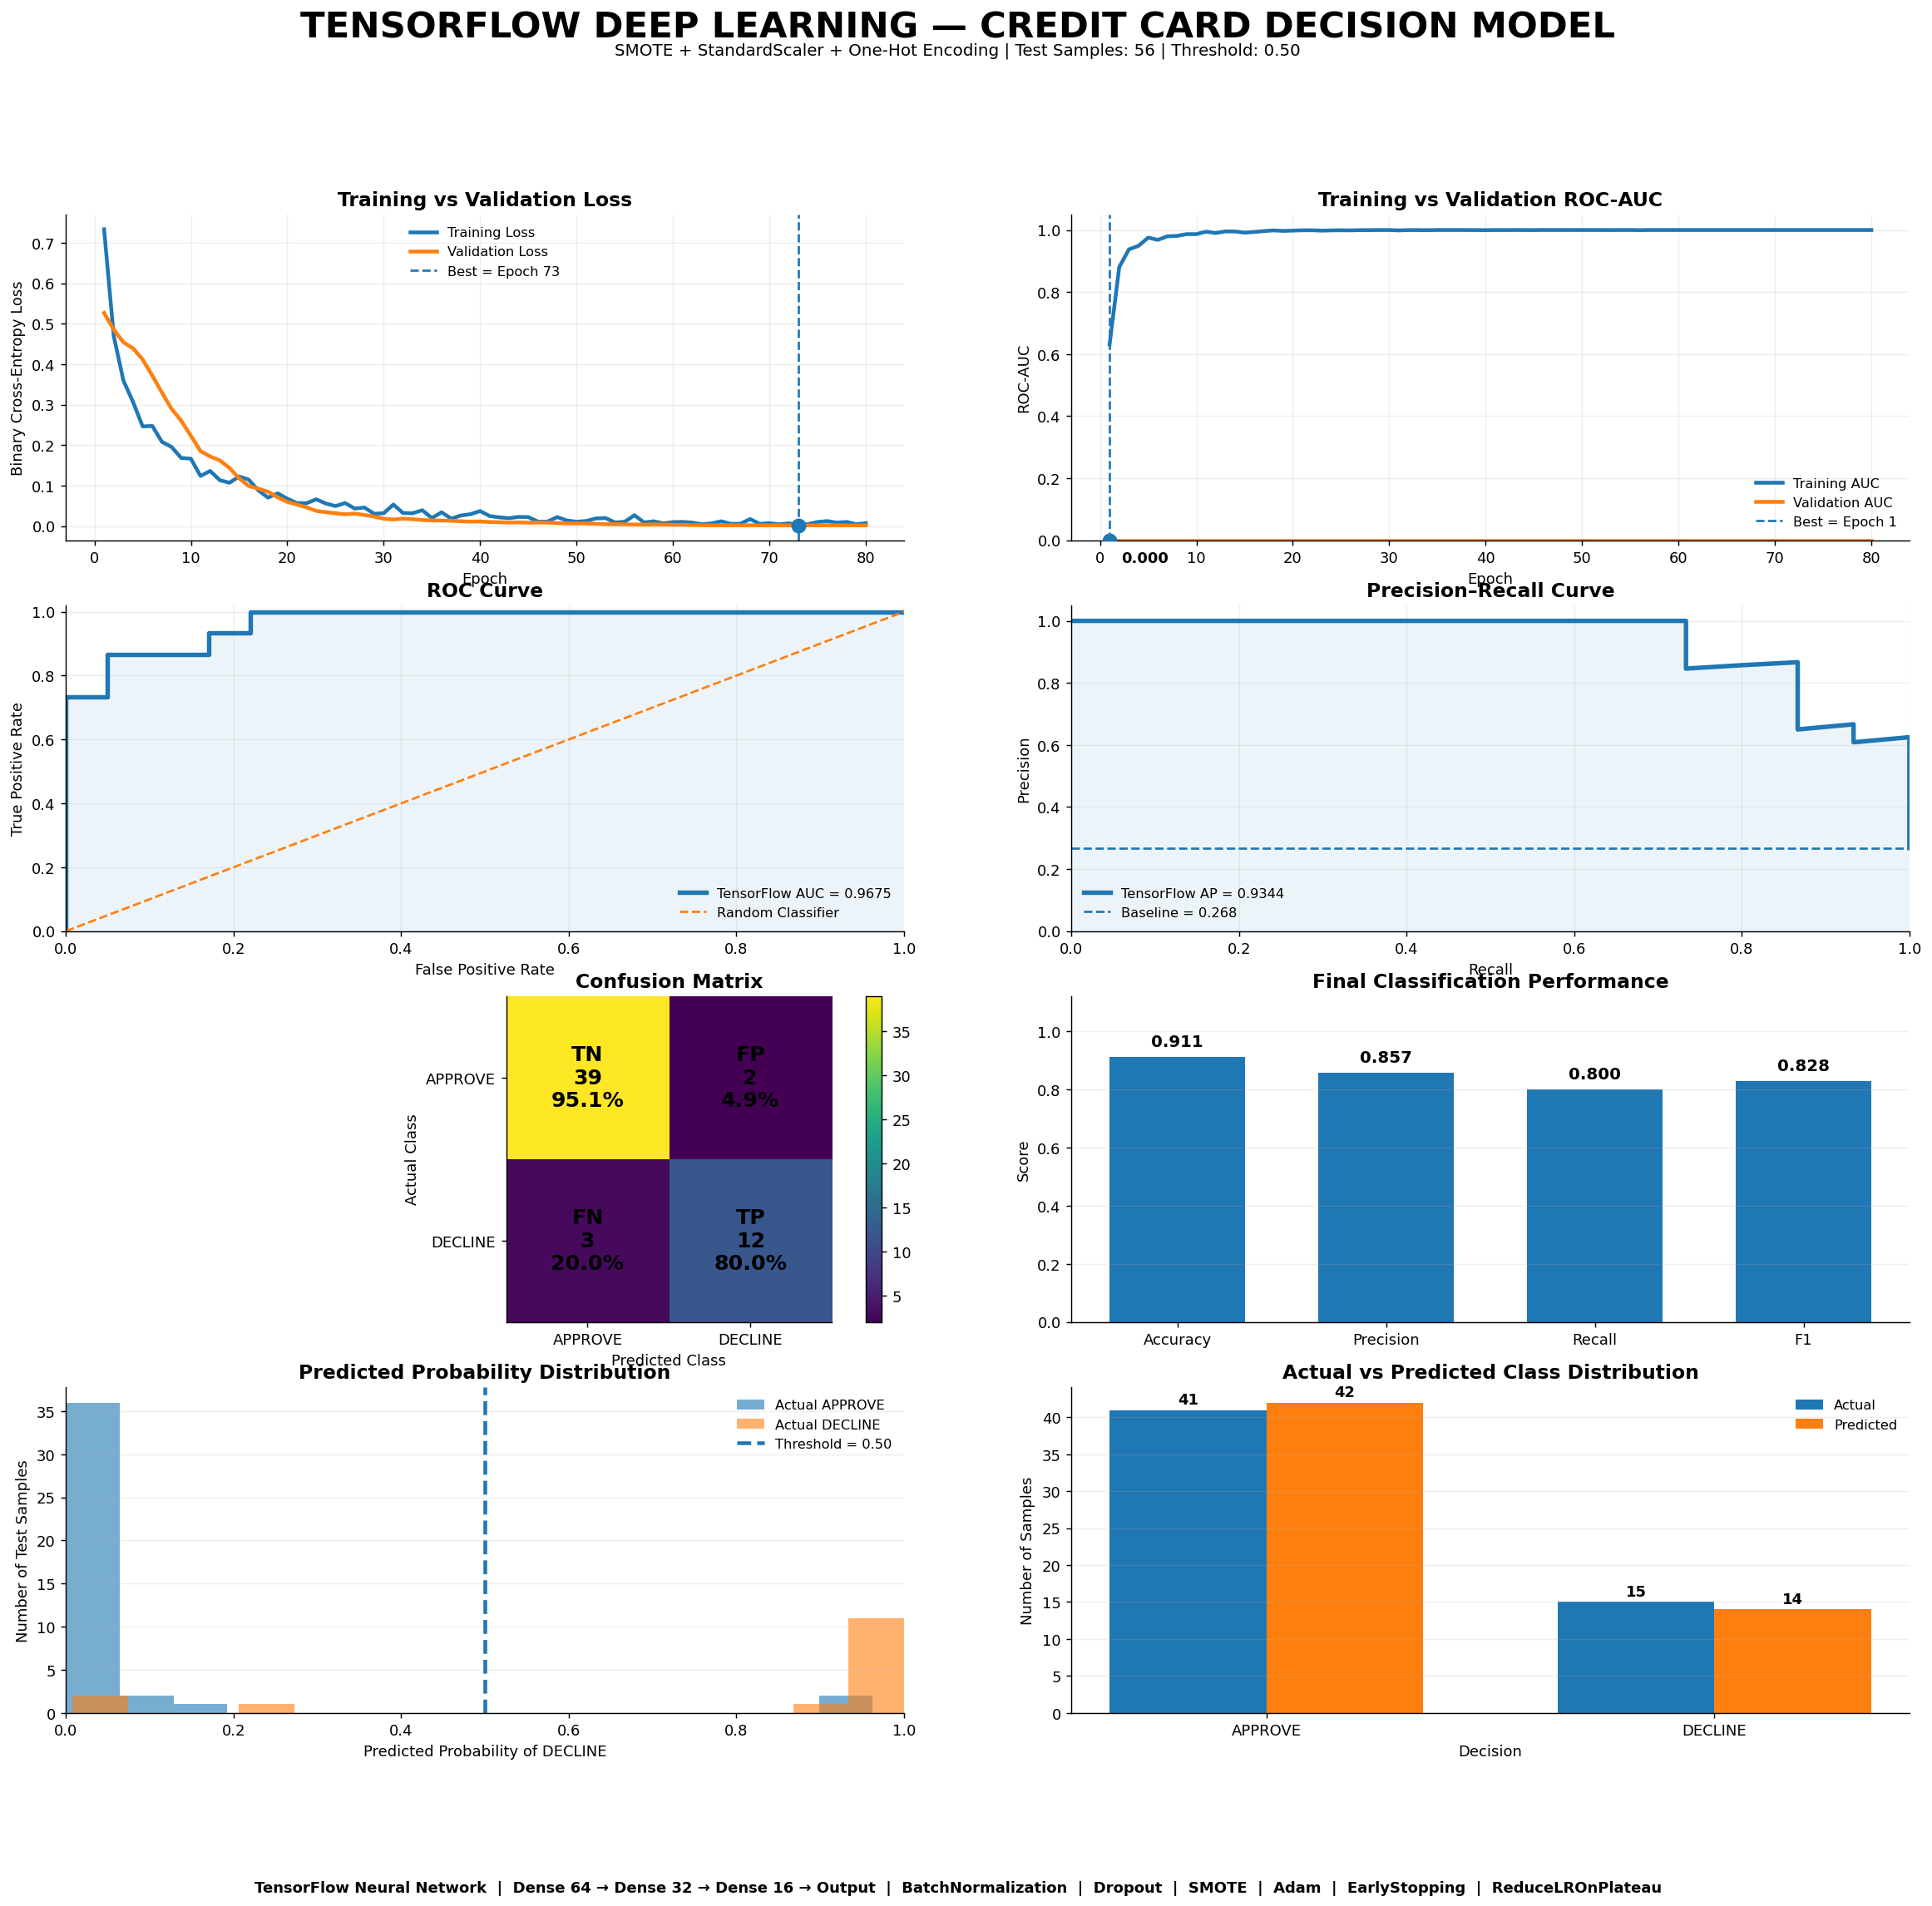


BETTER STATIC DASHBOARD CREATED

Dashboard: /content/TENSORFLOW_BETTER_STATIC_DASHBOARD.png


In [ ]:
# ================================================================
# BETTER TENSORFLOW DL STATIC DASHBOARD
#
# ax1 -> Training / Validation Loss
# ax2 -> Training / Validation AUC
# ax3 -> ROC Curve
# ax4 -> Precision-Recall Curve
# ax5 -> Confusion Matrix
# ax6 -> Final Performance
# ax7 -> Probability Distribution
# ax8 -> Actual vs Predicted
# ================================================================


# ================================================================
# 1. VISUAL SETTINGS
# ================================================================

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 250,
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 9
})


# ================================================================
# 2. PREPARE DATA
# ================================================================

epochs = range(
    1,
    len(history.history["loss"]) + 1
)


# ================================================================
# CONFUSION MATRIX PERCENTAGES
# ================================================================

cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100


# ================================================================
# ACTUAL / PREDICTED COUNTS
# ================================================================

actual_counts = [
    np.sum(y_test.values == 0),
    np.sum(y_test.values == 1)
]

predicted_counts = [
    np.sum(final_prediction == 0),
    np.sum(final_prediction == 1)
]


# ================================================================
# 3. CREATE FIGURE
# ================================================================

fig = plt.figure(
    figsize=(22, 18),
    facecolor="white"
)


# ================================================================
# MAIN TITLE
# ================================================================

fig.suptitle(
    "TENSORFLOW DEEP LEARNING — CREDIT CARD DECISION MODEL",
    fontsize=24,
    fontweight="bold",
    y=0.985
)


# ================================================================
# SUBTITLE
# ================================================================

fig.text(
    0.50,
    0.962,
    (
        f"SMOTE + StandardScaler + One-Hot Encoding | "
        f"Test Samples: {len(y_test)} | "
        f"Threshold: {THRESHOLD:.2f}"
    ),
    ha="center",
    fontsize=11
)


# ================================================================
# 4. CREATE AXES
# ================================================================

ax1 = fig.add_subplot(4, 2, 1)

ax2 = fig.add_subplot(4, 2, 2)

ax3 = fig.add_subplot(4, 2, 3)

ax4 = fig.add_subplot(4, 2, 4)

ax5 = fig.add_subplot(4, 2, 5)

ax6 = fig.add_subplot(4, 2, 6)

ax7 = fig.add_subplot(4, 2, 7)

ax8 = fig.add_subplot(4, 2, 8)


# ================================================================
# AX1 — LOSS
# ================================================================

ax1.plot(
    epochs,
    history.history["loss"],
    linewidth=2.5,
    label="Training Loss"
)

ax1.plot(
    epochs,
    history.history["val_loss"],
    linewidth=2.5,
    label="Validation Loss"
)

ax1.axvline(
    best_epoch_loss,
    linestyle="--",
    linewidth=1.5,
    label=f"Best = Epoch {best_epoch_loss}"
)

ax1.scatter(
    best_epoch_loss,
    history.history["val_loss"][best_epoch_loss - 1],
    s=80,
    zorder=5
)

ax1.set_title(
    "Training vs Validation Loss"
)

ax1.set_xlabel(
    "Epoch"
)

ax1.set_ylabel(
    "Binary Cross-Entropy Loss"
)

ax1.legend(
    frameon=False
)

ax1.grid(
    alpha=0.20
)


# ================================================================
# AX2 — AUC
# ================================================================

ax2.plot(
    epochs,
    history.history["auc"],
    linewidth=2.5,
    label="Training AUC"
)

ax2.plot(
    epochs,
    history.history["val_auc"],
    linewidth=2.5,
    label="Validation AUC"
)

ax2.axvline(
    best_epoch_auc,
    linestyle="--",
    linewidth=1.5,
    label=f"Best = Epoch {best_epoch_auc}"
)

best_auc_value = max(
    history.history["val_auc"]
)

ax2.scatter(
    best_epoch_auc,
    best_auc_value,
    s=80,
    zorder=5
)

ax2.annotate(
    f"{best_auc_value:.3f}",
    xy=(
        best_epoch_auc,
        best_auc_value
    ),
    xytext=(8, -15),
    textcoords="offset points",
    fontweight="bold"
)

ax2.set_title(
    "Training vs Validation ROC-AUC"
)

ax2.set_xlabel(
    "Epoch"
)

ax2.set_ylabel(
    "ROC-AUC"
)

ax2.set_ylim(
    0,
    1.05
)

ax2.legend(
    frameon=False
)

ax2.grid(
    alpha=0.20
)


# ================================================================
# AX3 — ROC CURVE
# ================================================================

ax3.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"TensorFlow AUC = {auc:.4f}"
)

ax3.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

ax3.fill_between(
    fpr,
    tpr,
    alpha=0.08
)

ax3.set_title(
    "ROC Curve"
)

ax3.set_xlabel(
    "False Positive Rate"
)

ax3.set_ylabel(
    "True Positive Rate"
)

ax3.set_xlim(
    0,
    1
)

ax3.set_ylim(
    0,
    1.02
)

ax3.legend(
    frameon=False,
    loc="lower right"
)

ax3.grid(
    alpha=0.20
)


# ================================================================
# AX4 — PRECISION RECALL
# ================================================================

ax4.plot(
    pr_recall,
    pr_precision,
    linewidth=3,
    label=f"TensorFlow AP = {ap:.4f}"
)

ax4.axhline(
    y=y_test.mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline = {y_test.mean():.3f}"
)

ax4.fill_between(
    pr_recall,
    pr_precision,
    alpha=0.08
)

ax4.set_title(
    "Precision–Recall Curve"
)

ax4.set_xlabel(
    "Recall"
)

ax4.set_ylabel(
    "Precision"
)

ax4.set_xlim(
    0,
    1
)

ax4.set_ylim(
    0,
    1.05
)

ax4.legend(
    frameon=False,
    loc="lower left"
)

ax4.grid(
    alpha=0.20
)


# ================================================================
# AX5 — CONFUSION MATRIX
# ================================================================

im = ax5.imshow(
    cm,
    interpolation="nearest",
    aspect="equal"
)

ax5.set_title(
    "Confusion Matrix"
)

ax5.set_xlabel(
    "Predicted Class"
)

ax5.set_ylabel(
    "Actual Class"
)

ax5.set_xticks(
    [0, 1]
)

ax5.set_yticks(
    [0, 1]
)

ax5.set_xticklabels(
    [
        "APPROVE",
        "DECLINE"
    ]
)

ax5.set_yticklabels(
    [
        "APPROVE",
        "DECLINE"
    ]
)


# ================================================================
# CONFUSION MATRIX ANNOTATIONS
# ================================================================

labels = [
    ["TN", "FP"],
    ["FN", "TP"]
]

for i in range(2):

    for j in range(2):

        ax5.text(
            j,
            i,
            (
                f"{labels[i][j]}\n"
                f"{cm[i, j]}\n"
                f"{cm_percent[i, j]:.1f}%"
            ),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold"
        )


fig.colorbar(
    im,
    ax=ax5,
    fraction=0.046,
    pad=0.04
)


# ================================================================
# AX6 — PERFORMANCE
# ================================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

metric_values = [
    accuracy,
    precision,
    recall,
    f1
]

bars = ax6.bar(
    metric_names,
    metric_values,
    width=0.65
)

ax6.set_title(
    "Final Classification Performance"
)

ax6.set_ylabel(
    "Score"
)

ax6.set_ylim(
    0,
    1.12
)

ax6.grid(
    axis="y",
    alpha=0.20
)


# ================================================================
# BAR VALUE LABELS
# ================================================================

for bar, value in zip(
    bars,
    metric_values
):

    ax6.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 0.025,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


# ================================================================
# AX7 — PROBABILITY DISTRIBUTION
# ================================================================

ax7.hist(
    approve_probs,
    bins=15,
    alpha=0.60,
    label="Actual APPROVE"
)

ax7.hist(
    decline_probs,
    bins=15,
    alpha=0.60,
    label="Actual DECLINE"
)

ax7.axvline(
    THRESHOLD,
    linestyle="--",
    linewidth=2.5,
    label=f"Threshold = {THRESHOLD:.2f}"
)

ax7.set_title(
    "Predicted Probability Distribution"
)

ax7.set_xlabel(
    "Predicted Probability of DECLINE"
)

ax7.set_ylabel(
    "Number of Test Samples"
)

ax7.set_xlim(
    0,
    1
)

ax7.legend(
    frameon=False
)

ax7.grid(
    axis="y",
    alpha=0.20
)


# ================================================================
# AX8 — ACTUAL VS PREDICTED
# ================================================================

x = np.arange(2)

width = 0.35

bars_actual = ax8.bar(
    x - width / 2,
    actual_counts,
    width,
    label="Actual"
)

bars_predicted = ax8.bar(
    x + width / 2,
    predicted_counts,
    width,
    label="Predicted"
)

ax8.set_title(
    "Actual vs Predicted Class Distribution"
)

ax8.set_xlabel(
    "Decision"
)

ax8.set_ylabel(
    "Number of Samples"
)

ax8.set_xticks(
    x
)

ax8.set_xticklabels(
    [
        "APPROVE",
        "DECLINE"
    ]
)

ax8.legend(
    frameon=False
)

ax8.grid(
    axis="y",
    alpha=0.20
)


# ================================================================
# VALUE LABELS — AX8
# ================================================================

for bar in bars_actual:

    ax8.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{int(bar.get_height())}",
        ha="center",
        fontweight="bold"
    )


for bar in bars_predicted:

    ax8.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{int(bar.get_height())}",
        ha="center",
        fontweight="bold"
    )


# ================================================================
# 5. BOTTOM MODEL INFORMATION
# ================================================================

fig.text(
    0.50,
    0.018,
    (
        "TensorFlow Neural Network  |  "
        "Dense 64 → Dense 32 → Dense 16 → Output  |  "
        "BatchNormalization  |  Dropout  |  SMOTE  |  "
        "Adam  |  EarlyStopping  |  ReduceLROnPlateau"
    ),
    ha="center",
    fontsize=10,
    fontweight="bold"
)


# ================================================================
# 6. SAVE DASHBOARD
# ================================================================

DASHBOARD_OUTPUT = (
    "/content/"
    "TENSORFLOW_BETTER_STATIC_DASHBOARD.png"
)

fig.savefig(
    DASHBOARD_OUTPUT,
    dpi=250,
    bbox_inches="tight",
    facecolor="white"
)


# ================================================================
# 7. SHOW DASHBOARD
# ================================================================

plt.show()


# ================================================================
# 8. FINAL DASHBOARD LOCATION
# ================================================================

print("\n" + "=" * 75)
print("BETTER STATIC DASHBOARD CREATED")
print("=" * 75)

print(
    "\nDashboard:",
    DASHBOARD_OUTPUT
)

# Credit Card Decision Analytics — Complete Machine Learning Analysis

## 1. Project Overview

This notebook presents an end-to-end machine learning analysis for **credit-card decision classification**, where each application/transaction is classified into one of two decisions:

* **APPROVE = 0**
* **DECLINE = 1**

The dataset combines observations from **Round 1 and Round 2**, as noted in the original analysis.

The primary objective is to build predictive models that can distinguish between approved and declined cases while paying particular attention to the minority **DECLINE** class.

Two major modeling approaches were developed:

1. **TensorFlow Deep Learning Neural Network**
2. **Advanced Machine Learning Stacking Ensemble**

The analysis includes:

* Data loading and target preparation
* Feature selection
* Stratified train/test splitting
* Missing-value handling
* Feature scaling
* One-hot encoding
* SMOTE class balancing
* Neural-network modeling
* Multiple classical machine-learning models
* Multiple feature-scaling strategies
* Logistic-regression meta-model stacking
* Weighted probability blending
* ROC-AUC evaluation
* Average Precision evaluation
* Accuracy, precision, recall and F1-score
* Confusion-matrix analysis
* ROC curves
* Precision–Recall curves
* Prediction-probability analysis
* Model comparison
* Final decision-oriented interpretation

---

# 2. Dataset Overview

The dataset used by the notebook contains:

* **280 total records**
* **13 original columns**

The target variable is:

```text
decision
```

The observed target distribution is:

| Decision  | Encoding |   Count | Proportion |
| --------- | -------: | ------: | ---------: |
| APPROVE   |        0 |     207 |     73.93% |
| DECLINE   |        1 |      73 |     26.07% |
| **Total** |          | **280** |   **100%** |

Therefore, the dataset is **imbalanced**, with APPROVE being the majority class and DECLINE being the minority class.

This imbalance is important because a model could obtain apparently strong accuracy simply by predicting APPROVE frequently. Consequently, the analysis does not rely on accuracy alone. Particular attention is given to:

* Precision for DECLINE
* Recall for DECLINE
* F1-score for DECLINE
* ROC-AUC
* Average Precision
* Confusion matrix

---

# 3. Target Variable Definition

The original `decision` variable is converted into a binary numerical target.

The encoding is:

```text
APPROVE → 0
DECLINE  → 1
```

If the target is stored as text, the notebook:

1. Converts it to string
2. Removes leading/trailing whitespace
3. Converts values to uppercase
4. Maps APPROVE to 0
5. Maps DECLINE to 1
6. Checks for invalid or missing target values
7. Converts the final target to integer format

This produces a clean binary classification target suitable for both TensorFlow and scikit-learn models.

---

# 4. Feature Selection

The notebook removes the following columns from the predictive feature matrix:

```text
id
score
decision
```

The `decision` column is removed because it is the target itself.

The `id` column is excluded because it is an identifier rather than a meaningful predictive variable.

The `score` column is also excluded from the machine-learning feature matrix.

The remaining predictive variables are:

### Numerical Features

```text
account_age_days
account_balance
amount
beneficiaries
linked_cards
months_active
recent_chargebacks
trust_score
utilisation
```

### Categorical Feature

```text
channel
```

Therefore, the model uses:

* **9 numerical variables**
* **1 categorical variable**

for a total of **10 original predictive columns**.

---

# 5. Train/Test Split

The dataset is divided into:

```text
Training set = 224 observations
Testing set  = 56 observations
```

The split uses:

```python
test_size = 0.20
random_state = 42
stratify = y
```

The use of stratification is important because the target is imbalanced.

Stratification attempts to preserve the APPROVE/DECLINE class distribution in both the training and testing datasets.

The test set contains:

```text
56 observations
41 APPROVE
15 DECLINE
```

The test set is kept separate from model fitting and is used for the final evaluation.

---

# 6. Data Preprocessing

The notebook applies preprocessing separately to numerical and categorical variables.

## 6.1 Numerical Preprocessing

The numerical pipeline consists of:

```text
Median Imputation
        ↓
StandardScaler
```

### Median Imputation

Missing numerical observations are replaced using the median of the corresponding training feature.

Median imputation is relatively robust to extreme values and prevents missing observations from causing model-training errors.

### StandardScaler

Numerical variables are standardized using:

```text
z = (x - mean) / standard deviation
```

This puts numerical variables on a comparable scale.

Scaling is particularly relevant for:

* Logistic Regression
* Neural Networks
* Distance-sensitive algorithms

---

# 7. Categorical Preprocessing

The categorical `channel` variable is processed using:

```text
Most-Frequent Imputation
        ↓
One-Hot Encoding
```

The notebook uses:

```python
OneHotEncoder(
    handle_unknown="ignore"
)
```

This converts the categorical channel into binary indicator variables.

The processed representation contains:

```text
channel_A
channel_B
channel_C
channel_D
```

Together with the nine numerical features, the final machine-learning representation contains:

**13 model input features.**

The processed feature structure is therefore:

```text
9 numerical features
+
4 channel dummy variables
=
13 model features
```

The use of:

```python
handle_unknown="ignore"
```

also prevents unseen categorical levels in the test set from causing transformation errors.

---

# 8. Prevention of Preprocessing Leakage

An important part of the workflow is that preprocessing is fitted only on the training data.

The notebook performs:

```python
preprocessor.fit_transform(X_train)
```

and then:

```python
preprocessor.transform(X_test)
```

The test set is therefore not used to calculate:

* Training means
* Training standard deviations
* Training medians
* Training categorical mappings

This prevents direct preprocessing leakage from the test set into the training process.

---

# 9. Class Imbalance and SMOTE

The original target distribution is:

```text
APPROVE = 207
DECLINE = 73
```

The training set is therefore also imbalanced.

To address this, the notebook applies:

**SMOTE — Synthetic Minority Over-sampling Technique**

SMOTE is applied **only to the training data**.

Before SMOTE:

```text
Training observations = 224
```

After preprocessing and SMOTE:

```text
Class 0 = 166
Class 1 = 166
Total   = 332
```

Thus, SMOTE creates a balanced training dataset:

| Class     | Before balancing | After SMOTE |
| --------- | ---------------: | ----------: |
| APPROVE   |              166 |         166 |
| DECLINE   |               58 |         166 |
| **Total** |          **224** |     **332** |

The original test data remains untouched.

This is important because synthetic observations should not be introduced into the final evaluation set.

---

# 10. Modeling Strategy I — TensorFlow Deep Learning

The first major modeling approach is a feed-forward neural network implemented using TensorFlow/Keras.

The model architecture is:

```text
13 Input Features
        ↓
Dense(64, ReLU)
        ↓
Batch Normalization
        ↓
Dropout(20%)
        ↓
Dense(32, ReLU)
        ↓
Batch Normalization
        ↓
Dropout(15%)
        ↓
Dense(16, ReLU)
        ↓
Dense(1, Sigmoid)
```

---

# 11. Neural Network Architecture

## Input Layer

The input dimension is:

```text
13 features
```

These correspond to the nine numerical variables plus the four one-hot encoded channel variables.

---

## First Hidden Layer

```python
Dense(64, activation="relu")
```

The first hidden layer contains 64 neurons.

ReLU is used because it provides a nonlinear activation function suitable for learning complex relationships.

---

## Batch Normalization

Batch normalization is applied after the first dense layer.

Its purpose is to stabilize and normalize intermediate activations during training, which can improve optimization.

---

## Dropout

The first dropout layer uses:

```text
Dropout = 0.20
```

This randomly disables a proportion of neurons during training and acts as a regularization mechanism.

---

## Second Hidden Layer

```python
Dense(32, activation="relu")
```

The network reduces the representation from 64 neurons to 32.

This allows the network to learn progressively more compact representations.

---

## Second Batch Normalization

Another batch-normalization layer is applied.

---

## Second Dropout

The second dropout layer uses:

```text
Dropout = 0.15
```

This provides additional regularization.

---

## Third Hidden Layer

```python
Dense(16, activation="relu")
```

The representation is further compressed to 16 neurons.

---

## Output Layer

The final layer is:

```python
Dense(1, activation="sigmoid")
```

The sigmoid activation produces a probability between 0 and 1.

The probability represents the estimated probability of:

```text
DECLINE
```

Therefore:

```text
Probability >= 0.50 → DECLINE
Probability < 0.50  → APPROVE
```

---

# 12. Neural Network Training Configuration

The neural network uses:

### Optimizer

```text
Adam
```

with:

```text
Learning rate = 0.001
```

### Loss Function

```text
Binary Cross-Entropy
```

This is appropriate for binary classification.

### Metrics

The network monitors:

```text
Accuracy
ROC-AUC
```

### Training Parameters

```text
Maximum epochs = 80
Batch size = 16
Validation split = 15%
```

---

# 13. Training Controls

Two callbacks are used.

## Early Stopping

The model monitors:

```text
validation loss
```

with:

```text
patience = 8
restore_best_weights = True
```

This is designed to stop training if validation loss stops improving.

## Reduce Learning Rate on Plateau

The learning rate is reduced by:

```text
factor = 0.5
```

when validation loss stops improving for:

```text
4 epochs
```

with a minimum learning rate of:

```text
0.00001
```

These mechanisms are designed to improve training stability and reduce unnecessary optimization.

---

# 14. TensorFlow Model Results

The TensorFlow model was evaluated on the untouched 56-observation test set.

The reported results are:

| Metric              |      Score |
| ------------------- | ---------: |
| ROC-AUC             | **0.9675** |
| Average Precision   | **0.9344** |
| Accuracy            | **0.9107** |
| Precision — DECLINE | **0.8571** |
| Recall — DECLINE    | **0.8000** |
| F1 — DECLINE        | **0.8276** |

The classification report is:

| Class                | Precision | Recall |         F1 | Support |
| -------------------- | --------: | -----: | ---------: | ------: |
| APPROVE              |    0.9286 | 0.9512 |     0.9398 |      41 |
| DECLINE              |    0.8571 | 0.8000 |     0.8276 |      15 |
| **Overall Accuracy** |           |        | **0.9107** |  **56** |

---

# 15. TensorFlow Confusion Matrix

The TensorFlow confusion matrix is:

```text
[[39,  2],
 [ 3, 12]]
```

Interpreting the matrix:

```text
True Negatives  = 39
False Positives = 2
False Negatives = 3
True Positives  = 12
```

Because class 0 represents APPROVE and class 1 represents DECLINE:

### 39 True Negatives

39 approved cases were correctly identified as APPROVE.

### 2 False Positives

2 approved cases were incorrectly classified as DECLINE.

### 3 False Negatives

3 declined cases were incorrectly classified as APPROVE.

### 12 True Positives

12 declined cases were correctly identified as DECLINE.

For a credit decision problem, the **3 false negatives** are particularly important because these represent declined cases that the model would have classified as approved.

---

# 16. TensorFlow ROC-AUC Interpretation

The TensorFlow model achieved:

```text
ROC-AUC = 0.9675
```

This indicates strong ranking ability on the held-out test data.

ROC-AUC evaluates how well the model separates the two classes across different probability thresholds rather than evaluating only the fixed 0.50 threshold.

The model therefore demonstrates strong discriminatory performance in this particular test sample.

---

# 17. TensorFlow Precision–Recall Analysis

The model achieved:

```text
Average Precision = 0.9344
```

Average Precision is particularly useful when the positive class is not dominant.

Here, the positive class is:

```text
DECLINE
```

The precision–recall analysis therefore provides information about the model's ability to identify declined cases while controlling false positives.

---

# 18. TensorFlow Probability Analysis

The notebook also examines the distribution of predicted probabilities separately for:

```text
Actual APPROVE
Actual DECLINE
```

The probability represents:

```text
P(DECLINE)
```

The threshold is:

```text
0.50
```

This visualization is useful for understanding whether the two classes produce clearly separated probability distributions or whether substantial overlap remains.

---

# 19. Modeling Strategy II — Advanced ML Stacking

The second major modeling strategy uses an ensemble of classical machine-learning algorithms.

The pipeline deliberately evaluates multiple numerical feature representations.

Four scaling approaches are used:

1. StandardScaler
2. RobustScaler
3. PowerTransformer
4. QuantileTransformer

---

# 20. Advanced Scaling Strategies

## Standard Scaling

StandardScaler transforms variables toward:

```text
mean ≈ 0
standard deviation ≈ 1
```

---

## Robust Scaling

RobustScaler uses quantile-based statistics and is less sensitive to extreme observations.

The notebook uses:

```text
quantile_range = (10, 90)
```

---

## Power Transformation

The PowerTransformer uses:

```text
Yeo-Johnson transformation
```

with standardization.

This can help make skewed numerical variables more Gaussian-like.

---

## Quantile Transformation

The QuantileTransformer uses:

```text
n_quantiles = 50
output_distribution = normal
```

This transforms the empirical distribution toward a normal distribution.

---

# 21. Base Models

The advanced ML ensemble trains nine base models:

1. Logistic Regression — Standard
2. Logistic Regression — Robust
3. Logistic Regression — Power
4. Logistic Regression — Quantile
5. Random Forest
6. Extra Trees
7. Gradient Boosting
8. HistGradientBoosting
9. XGBoost

Each model generates a probability of:

```text
DECLINE
```

These probabilities are subsequently used as inputs to the stacking layer.

---

# 22. Base Model Performance

The notebook reports the following test-set performance:

| Model                          |    ROC-AUC | Average Precision | Accuracy |         F1 |
| ------------------------------ | ---------: | ----------------: | -------: | ---------: |
| Logistic Regression — Standard | **0.9772** |        **0.9568** |   0.9107 |     0.8387 |
| Logistic Regression — Robust   |     0.9675 |            0.9397 |   0.8929 |     0.8125 |
| Gradient Boosting              |     0.9675 |            0.9377 |   0.9107 | **0.8485** |
| Logistic Regression — Power    |     0.9659 |            0.9334 |   0.8571 |     0.7647 |
| Logistic Regression — Quantile |     0.9626 |            0.9167 |   0.9107 |     0.8387 |
| XGBoost                        |     0.9577 |            0.8995 |   0.9107 | **0.8485** |
| HistGradientBoosting           |     0.9561 |            0.9001 |   0.8750 |     0.7879 |
| Extra Trees                    |     0.9415 |            0.8759 |   0.9107 |     0.8148 |
| Random Forest                  |     0.9268 |            0.8045 |   0.8571 |     0.7647 |

An important observation is that the **StandardScaler Logistic Regression model produced the highest individual ROC-AUC of 0.9772**.

However, the final ensemble is not selected purely according to ROC-AUC. The final decision system combines model probabilities to achieve a different balance between false positives and false negatives.

---

# 23. Stacking Architecture

The nine base-model prediction probabilities are combined into a stacking matrix.

The training stacking matrix has:

```text
332 rows × 9 model probabilities
```

The test stacking matrix has:

```text
56 rows × 9 model probabilities
```

Each row therefore contains the probability predictions generated by the nine base models.

These predictions become the input features for the meta-model.

---

# 24. Meta Model

The meta-model is:

```text
Logistic Regression
```

with:

```text
C = 0.5
solver = lbfgs
max_iter = 3000
```

The meta-model learns how to combine the probability outputs from the base models.

The purpose of stacking is to allow different models to contribute complementary information rather than relying on a single classifier.

---

# 25. Weighted Probability Blending

In addition to the logistic-regression stacking model, the notebook creates a weighted probability blend.

The weighting strategy gives slightly greater weight to selected tree-based models:

```text
Gradient Boosting → 1.15
XGBoost → 1.15
Extra Trees → 1.15
HistGradientBoosting → 1.10
Other models → 1.00
```

The weights are normalized before calculating the weighted average.

The final probability is then constructed as:

```text
Final Probability
=
0.75 × Stacking Probability
+
0.25 × Weighted Blend Probability
```

Therefore:

```text
75% → Logistic Regression Meta-Model
25% → Weighted Base-Model Blend
```

The final classification threshold is:

```text
0.50
```

---

# 26. Final Advanced ML Stacking Results

The final ensemble produces:

| Metric              |      Score |
| ------------------- | ---------: |
| ROC-AUC             | **0.9675** |
| Average Precision   | **0.9297** |
| Accuracy            | **0.9286** |
| Precision — DECLINE | **0.8235** |
| Recall — DECLINE    | **0.9333** |
| F1 — DECLINE        | **0.8750** |

Classification report:

| Class                | Precision | Recall |         F1 | Support |
| -------------------- | --------: | -----: | ---------: | ------: |
| APPROVE              |    0.9744 | 0.9268 |     0.9500 |      41 |
| DECLINE              |    0.8235 | 0.9333 |     0.8750 |      15 |
| **Overall Accuracy** |           |        | **0.9286** |  **56** |

---

# 27. Final Advanced ML Confusion Matrix

The final ensemble produces:

```text
[[38,  3],
 [ 1, 14]]
```

Therefore:

```text
True Negatives  = 38
False Positives = 3
False Negatives = 1
True Positives  = 14
```

This is particularly important from a decision perspective.

The final ensemble identifies:

```text
14 out of 15 actual DECLINE cases
```

which corresponds to:

```text
DECLINE Recall = 93.33%
```

Only:

```text
1 DECLINE case
```

is incorrectly classified as APPROVE.

---

# 28. Business Interpretation of the Final Ensemble

The final model demonstrates a strong ability to identify the minority DECLINE class.

The most important result is:

```text
Recall for DECLINE = 93.33%
```

This means the model successfully identifies approximately 93 out of every 100 declined cases in this test sample.

The trade-off is:

```text
Precision for DECLINE = 82.35%
```

Therefore, some cases predicted as DECLINE are actually APPROVE.

Specifically:

```text
3 False Positives
```

are observed.

In a credit-card decision environment, this trade-off can be meaningful.

If the primary business concern is:

> "Do not incorrectly approve cases that should be declined."

then minimizing false negatives may be more important than maximizing raw accuracy.

The final stacking model produces only:

```text
1 False Negative
```

compared with:

```text
3 False Negatives
```

for the TensorFlow model.

Thus, the ensemble provides a substantially stronger recall for the DECLINE class.

---

# 29. TensorFlow vs Advanced ML Stacking

The two major approaches can be compared directly:

| Metric              | TensorFlow | Advanced Stacking |
| ------------------- | ---------: | ----------------: |
| ROC-AUC             |     0.9675 |            0.9675 |
| Average Precision   | **0.9344** |            0.9297 |
| Accuracy            |     0.9107 |        **0.9286** |
| Precision — DECLINE | **0.8571** |            0.8235 |
| Recall — DECLINE    |     0.8000 |        **0.9333** |
| F1 — DECLINE        |     0.8276 |        **0.8750** |
| False Positives     |          2 |                 3 |
| False Negatives     |          3 |             **1** |
| True Positives      |         12 |            **14** |

---

# 30. Model Selection Interpretation

There is no single metric that determines the best model for every business objective.

The TensorFlow model has:

* Higher Average Precision
* Higher DECLINE precision
* Fewer false positives

The Advanced ML Stacking model has:

* Higher accuracy
* Much higher DECLINE recall
* Higher DECLINE F1
* Fewer false negatives
* More correctly identified declined cases

The most important distinction is:

```text
TensorFlow:
3 False Negatives

Advanced Stacking:
1 False Negative
```

Therefore, if the objective is to maximize the detection of cases that should be declined, the **Advanced ML Stacking model is preferable based on this test result**.

---

# 31. Why Accuracy Alone Is Not Sufficient

The dataset contains considerably more APPROVE cases than DECLINE cases.

Therefore, accuracy alone can hide poor minority-class performance.

For example, a model could obtain a high accuracy by predicting APPROVE for most observations.

That would not necessarily make it a useful credit-decision model.

The analysis therefore focuses on:

```text
ROC-AUC
Average Precision
Precision
Recall
F1-score
Confusion Matrix
```

This provides a much more complete evaluation.

---

# 32. Confusion-Matrix Decision Analysis

The confusion matrix provides direct information about the operational consequences of model predictions.

For the final Advanced ML model:

```text
                  Predicted
                APPROVE DECLINE

Actual APPROVE     38      3
Actual DECLINE      1     14
```

Therefore:

### Correct Approvals

```text
38
```

### Incorrect Declines

```text
3
```

These are APPROVE cases incorrectly flagged as DECLINE.

### Incorrect Approvals

```text
1
```

This is an actual DECLINE case incorrectly predicted as APPROVE.

### Correct Declines

```text
14
```

The model therefore captures the majority of declined cases.

---

# 33. ROC Curve

The ROC curve evaluates model discrimination over a range of classification thresholds.

The final stacking model achieves:

```text
ROC-AUC = 0.9675
```

The curve is compared with the random-classifier diagonal.

A model with ROC-AUC close to 1 has strong ability to rank positive and negative cases separately.

The observed result indicates strong discrimination on the available test set.

---

# 34. Precision–Recall Curve

The Precision–Recall curve focuses specifically on the positive class:

```text
DECLINE
```

The baseline precision corresponds to the prevalence of DECLINE in the test set:

```text
15 / 56 ≈ 0.268
```

The final model achieves:

```text
Average Precision = 0.9297
```

which is substantially higher than the positive-class baseline.

This supports the conclusion that the model is capable of ranking DECLINE cases substantially better than a naive baseline on this test set.

---

# 35. Probability Threshold

The notebook uses:

```text
Threshold = 0.50
```

The decision rule is:

```text
P(DECLINE) >= 0.50
        ↓
     DECLINE

P(DECLINE) < 0.50
        ↓
     APPROVE
```

The threshold is therefore an important business control.

Changing the threshold can change:

* False positives
* False negatives
* Precision
* Recall
* F1-score

For a production credit-decision system, the threshold should ideally be selected using business costs rather than automatically assuming 0.50 is optimal.

---

# 36. Important Methodological Limitation — Stacking

The notebook explicitly states:

```text
NO OOF
NO NESTED CV
TRAIN ONCE
```

This means the base-model predictions used to train the meta-model are **not generated using out-of-fold predictions**.

Instead, the base models generate predictions on the same training data used to fit them.

Consequently, the meta-model can potentially receive overly optimistic base-model predictions.

This creates a methodological limitation in the stacking procedure.

A more rigorous production/research implementation would use:

```text
K-Fold Cross-Validation
        ↓
Out-of-Fold Base Predictions
        ↓
Train Meta-Model
        ↓
Refit Base Models
        ↓
Evaluate on Completely Unseen Test Data
```

This would reduce the risk of information leakage into the stacking layer.

Therefore, the reported stacking metrics should be interpreted as **test-set results from the implemented pipeline**, but the stacking architecture should not yet be considered fully validated for production deployment.

---

# 37. Important Methodological Limitation — Small Dataset

The complete dataset contains only:

```text
280 observations
```

with:

```text
56 test observations
```

and only:

```text
15 DECLINE cases
```

in the test set.

Because the test set is relatively small, one or two observations can noticeably change:

* Recall
* Precision
* F1-score
* Accuracy
* Confusion matrix
* ROC-AUC

Therefore, the reported values are useful indicators but should not be interpreted as definitive estimates of real-world production performance.

A larger independent validation dataset would provide stronger evidence.

---

# 38. Neural Network Validation Diagnostic

One notable diagnostic from the TensorFlow training output is that the reported validation AUC remains:

```text
0.0000
```

while validation accuracy becomes extremely high.

This should be investigated before relying on the training AUC curve as a model-selection criterion.

The likely issue is related to the composition or evaluation behavior of the small validation subset after SMOTE and the Keras AUC calculation.

The notebook therefore uses validation loss for early stopping, while the final model evaluation is performed on the independent test set.

This reinforces the importance of using a larger and properly stratified validation framework for future experiments.

---

# 39. Reproducibility

The notebook fixes the random seed at:

```text
42
```

for:

* NumPy
* Python random
* TensorFlow
* SMOTE
* Relevant model components

This improves reproducibility of the experiment.

However, exact neural-network reproducibility can still depend on the execution environment, TensorFlow version, hardware and underlying numerical operations.

---

# 40. Overall Findings

The analysis demonstrates that the available transaction/account variables contain substantial predictive information for the APPROVE/DECLINE decision.

The strongest individual classical model by ROC-AUC was:

```text
Logistic Regression — StandardScaler

ROC-AUC = 0.9772
Average Precision = 0.9568
```

However, the final ensemble produced a better decision-oriented balance:

```text
Accuracy = 0.9286
DECLINE Recall = 0.9333
DECLINE F1 = 0.8750
```

The final ensemble also reduced false negatives to:

```text
1 case
```

out of the 15 actual DECLINE cases in the test set.

---

# 41. Final Model Recommendation

Based strictly on the notebook's reported test results, the **Advanced ML Stacking model is the preferred model for a decline-sensitive decision objective**.

The primary reason is its ability to identify the DECLINE class:

```text
Recall = 93.33%
F1 = 87.50%
False Negatives = 1
True Positives = 14
```

The TensorFlow model remains a strong alternative, particularly because it achieves:

```text
Average Precision = 93.44%
DECLINE Precision = 85.71%
```

Therefore, the final model choice depends on the business objective:

### If minimizing missed DECLINE cases is the priority:

**Advanced ML Stacking is preferred.**

### If minimizing incorrect DECLINE decisions is the priority:

**TensorFlow provides a higher DECLINE precision.**

### If overall classification accuracy is the priority:

**Advanced ML Stacking is preferred.**

---

# 42. Recommended Next Steps

Before production deployment, the following improvements are recommended:

### 1. Implement Out-of-Fold Stacking

Replace the current in-sample base predictions with genuine OOF predictions.

### 2. Increase Validation Data

Use a larger independent validation dataset if available.

### 3. Perform Repeated Stratified Cross-Validation

This will provide more stable estimates of model performance.

### 4. Perform Threshold Optimization

Instead of automatically using:

```text
0.50
```

evaluate thresholds based on the actual business cost of:

* False approvals
* False declines

### 5. Investigate Feature Importance

For the final selected model, investigate which variables contribute most strongly to the decision.

Potential variables of interest include:

```text
trust_score
recent_chargebacks
utilisation
amount
account_balance
account_age_days
months_active
beneficiaries
linked_cards
channel
```

### 6. Perform Model Calibration

Because the models output probabilities, calibration should be assessed before interpreting the probabilities as reliable risk probabilities.

### 7. Monitor Production Drift

After deployment, monitor changes in:

* Feature distributions
* Approval rate
* Decline rate
* Model probability distributions
* False-positive rate
* False-negative rate
* Recall for DECLINE

---

# 43. Final Conclusion

The notebook successfully develops and evaluates two different approaches for credit-card decision classification.

The TensorFlow neural network uses:

```text
StandardScaler
+
One-Hot Encoding
+
SMOTE
+
Dense 64
+
Dense 32
+
Dense 16
+
Batch Normalization
+
Dropout
+
Adam
```

and achieves:

```text
ROC-AUC = 0.9675
Accuracy = 0.9107
DECLINE Precision = 0.8571
DECLINE Recall = 0.8000
DECLINE F1 = 0.8276
```

The Advanced ML approach evaluates multiple feature transformations and nine base models before combining their predictions through a logistic-regression meta-model and weighted probability blending.

The final Advanced ML Stacking model achieves:

```text
ROC-AUC = 0.9675
Average Precision = 0.9297
Accuracy = 0.9286
DECLINE Precision = 0.8235
DECLINE Recall = 0.9333
DECLINE F1 = 0.8750
```

with the final confusion matrix:

```text
[[38, 3],
 [ 1, 14]]
```

The key decision-oriented finding is therefore:

> **The Advanced ML Stacking model provides the strongest overall decision performance in this experiment, primarily because it identifies 14 of the 15 actual DECLINE cases while producing only 1 false negative.**

At the same time, the model should **not yet be considered production-ready** because the dataset is small and the stacking procedure does not use out-of-fold predictions.

The results should therefore be interpreted as a strong experimental/model-development result rather than as definitive evidence of real-world deployment performance.

---

## Final Model Summary

| Component               | Final Configuration            |
| ----------------------- | ------------------------------ |
| Dataset                 | Round 1 + Round 2              |
| Total Records           | 280                            |
| Original Columns        | 13                             |
| ML Features             | 10                             |
| Processed Features      | 13                             |
| Target                  | APPROVE / DECLINE              |
| Target Encoding         | APPROVE = 0, DECLINE = 1       |
| Train Samples           | 224                            |
| Test Samples            | 56                             |
| Class Balancing         | SMOTE                          |
| Base Models             | 9                              |
| Scaling Methods         | 4                              |
| Meta Model              | Logistic Regression            |
| Final Combination       | 75% Stack + 25% Weighted Blend |
| Threshold               | 0.50                           |
| Final ROC-AUC           | **0.9675**                     |
| Final Average Precision | **0.9297**                     |
| Final Accuracy          | **0.9286**                     |
| Final DECLINE Precision | **0.8235**                     |
| Final DECLINE Recall    | **0.9333**                     |
| Final DECLINE F1        | **0.8750**                     |
| False Positives         | **3**                          |
| False Negatives         | **1**                          |
| True Positives          | **14**                         |
| True Negatives          | **38**                         |

### Final Interpretation

**The model demonstrates strong predictive separation between APPROVE and DECLINE cases on the available test set. The Advanced ML Stacking approach is the stronger decision-oriented model when detecting DECLINE cases is the primary objective. However, additional validation, OOF stacking, threshold optimization, calibration, and larger datasets are required before production deployment.**
